# TBI Patients — Incident & Outcomes EDA (v3)

Same analysis as **v2**, with two changes:

1. **Seven main mechanism categories** — Fall, Transportation, Struck by/against,
   Assault, Unspecified, Late effect, Natural/environmental — plus a **Multiple**
   bucket for patients whose external-cause codes span more than one of those seven.
   These are the seven largest mechanism families in the cohort.
2. **Full-code ICD-9 matching.** v2 keyed its lookup off the 4-character ICD-9 prefix
   (e.g. `E968`). That prefix has subdivisions mapped to *four* different mechanisms
   (`E968.0` = Fire, `E968.1` = Fall, `E968.2` = Struck-by, `E968.4–.9` = Assault), so
   the first-seen mechanism was applied to every `E968` patient and silently masked the
   real assaults. v3 keys off the full 5-character ICD-9 code (`E9684`, `E9689`, …) and
   only falls back to the 4-char prefix when **every** 5-char child of that prefix
   agrees on the same mechanism — so the per-category counts are now correct.

The downstream sections (subcategory shortlist, discharge buckets, LOS, age/GCS) all
key off the new 7-category set.


## 0 · Setup

In [1]:
import os, re, warnings
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"]       = 110
plt.rcParams["axes.titlesize"]   = 12
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_columns", None)

# ---- 7 main mechanism families (ordered roughly by expected size) + Multiple ----
MAIN_CATS = [
    "Fall",
    "Transportation",
    "Struck by/against",
    "Assault",
    "Unspecified",
    "Late effect",
    "Natural/environmental",
    "Multiple",
]
MAIN_COLORS = {
    "Fall":                  "#4C72B0",  # blue
    "Transportation":        "#DD8452",  # orange
    "Struck by/against":     "#55A868",  # green
    "Assault":               "#C44E52",  # red
    "Unspecified":           "#8C8C8C",  # gray
    "Late effect":           "#937860",  # brown
    "Natural/environmental": "#64B5CD",  # teal
    "Multiple":              "#8172B3",  # purple
}
DISCH_ORDER = [
    "Home", "Home Health Care", "Skilled Nursing Facility",
    "Long-Term Care Facility", "Hospice", "Dead/Expired", "Other",
]
DISCH_COLORS = dict(zip(DISCH_ORDER, sns.color_palette("Set2", n_colors=len(DISCH_ORDER))))

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## 1 · Load patient data and Excel mapping

In [2]:
PATIENT_CSV = "TBI_INCIDENT_NEW.csv"
MATRIX_XLSX = "ICD_External_Cause_Matrix_CDC_Verified.xlsx"

df = pd.read_csv(PATIENT_CSV).drop_duplicates(subset="hadm_id").reset_index(drop=True)
print(f"Admissions: {len(df):,}   |   Unique patients: {df['subject_id'].nunique():,}")
df.head(3)

Admissions: 9,723   |   Unique patients: 9,723


,subject_id,hadm_id,admittime,dischtime,deathtime,discharge_location,hospital_expire_flag,hospital_los_days,icu_los_days,icu_intime,icu_outtime,disposition_category,all_icd_codes,total_codes,icd_version,age_at_admission,last_gcs_score
0,16676551,23907483,2124-07-16 23:56:00.000000 UTC,2124-07-17 11:28:00.000000 UTC,NaN,NaN,0,0.500000,NaN,NaN,NaN,other_unknown,"85221, E8148, 3441",3,9,35,NaN
1,12602845,29376163,2142-07-22 16:59:00.000000 UTC,2142-07-22 22:31:00.000000 UTC,NaN,NaN,0,0.250000,NaN,NaN,NaN,other_unknown,"95901, E9179, 29680, 8470",4,9,26,NaN
2,15868827,20387537,2153-07-11 23:08:00.000000 UTC,2153-07-12 06:20:00.000000 UTC,NaN,NaN,0,0.291667,NaN,NaN,NaN,other_unknown,"30500, 95901, E8888, 78097",4,9,46,NaN


In [3]:
overview = pd.DataFrame({
    "non_null": df.notna().sum(),
    "nulls":    df.isna().sum(),
    "null_%":   (df.isna().mean() * 100).round(1),
})
overview

,non_null,nulls,null_%
subject_id,9723,0,0.0
hadm_id,9723,0,0.0
admittime,9723,0,0.0
dischtime,9723,0,0.0
deathtime,519,9204,94.7
discharge_location,7163,2560,26.3
hospital_expire_flag,9723,0,0.0
hospital_los_days,9723,0,0.0
icu_los_days,3624,6099,62.7
icu_intime,3625,6098,62.7


## 2 · Build the incident-code lookup (full-code matching)

We parse the CDC Excel workbook to build:

| Lookup table | Key             | Used for                                                   |
|--------------|-----------------|------------------------------------------------------------|
| `EXACT9`     | 5-char ICD-9 (`E9684`) or 4-char standalone (`E882`, `E907`) | First lookup pass for every ICD-9 code we see |
| `PREFIX9`    | 4-char ICD-9 prefix (`E885`) | Fallback **only** when every 5-char child of that prefix maps to the same mechanism family |
| `EXACT10`    | 3-char ICD-10 (`W19`, `X92`) | Single-pass lookup for ICD-10 codes                       |

For each code we try the most specific entry first, then fall back. Ambiguous 4-char
prefixes like `E968` (children span Fall / Fire / Struck-by / Assault) are intentionally
**not** in `PREFIX9` — bare-4-char codes that need such a prefix would be unmatched
rather than miscategorised.

### Mechanism → main category rollup

| Main category           | Detailed CDC mechanisms folded in            |
|-------------------------|----------------------------------------------|
| Fall                    | every mechanism whose label contains `Fall`  |
| Transportation          | `MVT*`, `MV–Nontraffic`, `Transport*`, `Other land transport`, `Other transport`, `Pedestrian–other`, `Pedal cyclist–other` |
| Struck by/against       | mechanism contains `Struck`                  |
| Assault                 | mechanism starts with `Assault`              |
| Unspecified             | mechanism is exactly `Unspecified`           |
| Late effect             | mechanism contains `Late effect`             |
| Natural/environmental   | mechanism contains `Natural`                 |

Everything else (Firearm, Drowning, Fire/burn, Poisoning, Cut/pierce, Suffocation,
Machinery, Overexertion, Place/Activity/Status context codes) is *not* folded into the
seven target categories and is ignored when assigning patients.

In [4]:
DASH = "–"  # en-dash used in Excel ranges

def family(mech: str):
    """Collapse a detailed CDC mechanism into one of the 7 main families, or None."""
    m = str(mech).strip()
    if "Fall" in m:
        return "Fall"
    if (m.startswith("MVT") or m == "MV–Nontraffic" or m.startswith("Transport")
        or m in {"Other land transport", "Other transport",
                 "Pedestrian–other", "Pedal cyclist–other"}):
        return "Transportation"
    if m.startswith("Assault"):                return "Assault"
    if "Struck" in m:                          return "Struck by/against"
    if "Late effect" in m:                     return "Late effect"
    if "Natural" in m:                         return "Natural/environmental"
    if m == "Unspecified":                     return "Unspecified"
    return None


def expand9_full(rng):
    """Return all explicit ICD-9 code keys covered by an Excel range string."""
    rng = str(rng).strip()
    if rng.startswith("["):           # '[E810–E819].0' — 4th-digit subdivision, skip
        return []
    # decimal range  E880.0–E880.9
    m = re.match(rf"E(\d{{3}})\.(\d){DASH}E(\d{{3}})\.(\d)$", rng)
    if m and m.group(1) == m.group(3):
        p = f"E{int(m.group(1)):03d}"
        return [f"{p}{d}" for d in range(int(m.group(2)), int(m.group(4)) + 1)]
    # single decimal  E960.0
    m = re.match(r"E(\d{3})\.(\d)$", rng)
    if m:
        return [f"E{int(m.group(1)):03d}{m.group(2)}"]
    # bare 4-char range  E880–E888  → register 4-char + every 5-char subdivision
    m = re.match(rf"E(\d{{3}}){DASH}E(\d{{3}})$", rng)
    if m:
        out = []
        for n in range(int(m.group(1)), int(m.group(2)) + 1):
            p = f"E{n:03d}"
            out.append(p)
            out.extend(f"{p}{d}" for d in range(10))
        return out
    # single 4-char  E882, E907  → register the 4-char and its 5-char subs
    m = re.match(r"E(\d{3})$", rng)
    if m:
        p = f"E{int(m.group(1)):03d}"
        return [p] + [f"{p}{d}" for d in range(10)]
    return []


def expand10_full(rng):
    head = str(rng).split("(")[0].strip()
    m = re.match(rf"([VWXY])(\d{{2}}){DASH}([VWXY])(\d{{2}})$", head)
    if m and m.group(1) == m.group(3):
        return [f"{m.group(1)}{n:02d}" for n in range(int(m.group(2)), int(m.group(4)) + 1)]
    m = re.match(r"([VWXY]\d{2})(\.\d+)?$", head)
    if m:
        return [m.group(1)]
    return []


# ---- read both Excel sheets ----
df9 = pd.read_excel(MATRIX_XLSX, sheet_name="ICD-9 E-Codes (Mechanism)", header=3)
df9.columns = ["code_range", "description", "mechanism", "intent", "notes"]
df9 = df9.dropna(subset=["code_range", "description", "mechanism"])

df10 = pd.read_excel(MATRIX_XLSX, sheet_name="ICD-10 V-Y Codes (Mechanism)", header=3)
df10.columns = ["code_range", "description", "mechanism", "intent", "notes"]
df10 = df10.dropna(subset=["code_range", "description", "mechanism"])

# ---- build EXACT9 + PREFIX9 (fallback only when unambiguous) ----
EXACT9 = {}                          # code → (description, family)
SUB9   = defaultdict(set)            # 4-char prefix → set of (description, family)
for _, r in df9.iterrows():
    fam = family(r["mechanism"])
    if fam is None:
        continue
    for c in expand9_full(r["code_range"]):
        EXACT9.setdefault(c, (r["description"], fam))
        if len(c) >= 4:
            SUB9[c[:4]].add((r["description"], fam))
# only allow 4-char prefix fallback when every child agrees on one family
PREFIX9 = {p: next(iter(s))                           # take any description from the set
           for p, s in SUB9.items()
           if len({fam for _, fam in s}) == 1}

# ---- build EXACT10 ----
EXACT10 = {}
for _, r in df10.iterrows():
    fam = family(r["mechanism"])
    if fam is None:
        continue
    for c in expand10_full(r["code_range"]):
        EXACT10.setdefault(c, (r["description"], fam))

print(f"ICD-9  EXACT keys : {len(EXACT9):>4}")
print(f"ICD-9  PREFIX keys: {len(PREFIX9):>4}  (4-char fallback, unambiguous only)")
print(f"ICD-10 EXACT keys : {len(EXACT10):>4}")
print()
print("Sanity check on ambiguous prefix E968:")
print(f"  E968 in EXACT9    : {'E968' in EXACT9}")
print(f"  E968 in PREFIX9   : {'E968' in PREFIX9}   ← False (correct: children disagree)")
print(f"  EXACT9['E9681']   : {EXACT9.get('E9681')}")
print(f"  EXACT9['E9684']   : {EXACT9.get('E9684')}")
print(f"  EXACT9['E9689']   : {EXACT9.get('E9689')}")

ICD-9  EXACT keys :  784
ICD-9  PREFIX keys:   76  (4-char fallback, unambiguous only)
ICD-10 EXACT keys :  169

Sanity check on ambiguous prefix E968:
  E968 in EXACT9    : False
  E968 in PREFIX9   : False   ← False (correct: children disagree)
  EXACT9['E9681']   : ('Pushing from high place (homicide)', 'Fall')
  EXACT9['E9684']   : ('Other assault', 'Assault')
  EXACT9['E9689']   : ('Assault, unspecified means', 'Assault')


## 3 · Classify every patient

For each admission we scan `all_icd_codes`, identify external-cause codes per ICD
version, and record the set of (family, subcategory) pairs.

- **Single-category** patients are labelled with that family.
- **Multiple-category** patients (codes spanning **two or more** of the seven
  families) are labelled `Multiple`.
- Patients with **no** matching external-cause code are excluded from the
  categorical analysis; the count is reported below.

> *Note on the "Multiple" rule.* As in v2, we interpret "more than one external
> incident code" as *more than one distinct main family*. A patient with three
> fall codes but no other family is still classified as `Fall`.

In [5]:
def lookup_icd9(code):
    """Return (description, family) or None for a MIMIC ICD-9 code (no decimal)."""
    if code in EXACT9:           return EXACT9[code]
    if len(code) >= 5 and code[:5] in EXACT9: return EXACT9[code[:5]]
    if len(code) >= 4 and code[:4] in EXACT9: return EXACT9[code[:4]]
    if len(code) >= 4 and code[:4] in PREFIX9: return PREFIX9[code[:4]]
    return None


def lookup_icd10(code):
    return EXACT10.get(code[:3])


def classify(all_codes, version):
    main = set()
    subs = []      # list of (family, description)
    if pd.isna(all_codes):
        return main, subs
    for raw in str(all_codes).split(","):
        c = raw.strip().upper()
        if not c:
            continue
        if int(version) == 9:
            if not c.startswith("E"):     continue
            hit = lookup_icd9(c)
        else:
            if c[0] not in "VWXY":        continue
            hit = lookup_icd10(c)
        if hit:
            desc, fam = hit
            main.add(fam)
            subs.append((fam, desc))
    return main, subs


_main, _subs = zip(*df.apply(lambda r: classify(r["all_icd_codes"], r["icd_version"]),
                             axis=1))
df["main_set"]    = list(_main)
df["sub_hits"]    = list(_subs)
df["n_main_cats"] = df["main_set"].apply(len)

def assign_main(s):
    if len(s) == 0:      return None
    if len(s) == 1:      return next(iter(s))
    return "Multiple"

df["main_category"] = df["main_set"].apply(assign_main)

n_total      = len(df)
n_classified = df["main_category"].notna().sum()
n_dropped    = n_total - n_classified
print(f"Total admissions          : {n_total:,}")
print(f"Classified                : {n_classified:,} ({n_classified/n_total*100:.1f}%)")
print(f"No matching external code : {n_dropped:,} ({n_dropped/n_total*100:.1f}%)")
print()
print(df["main_category"].fillna("(none)").value_counts())

Total admissions          : 9,723
Classified                : 8,262 (85.0%)
No matching external code : 1,461 (15.0%)

main_category
Fall                     5487
Transportation           1599
(none)                   1461
Struck by/against         417
Assault                   238
Unspecified               191
Late effect               170
Multiple                  156
Natural/environmental       4
Name: count, dtype: int64


## 4 · Main-category distribution

Counts and shares across **Fall / Transportation / Struck by/against / Assault /
Unspecified / Late effect / Natural/environmental / Multiple**.

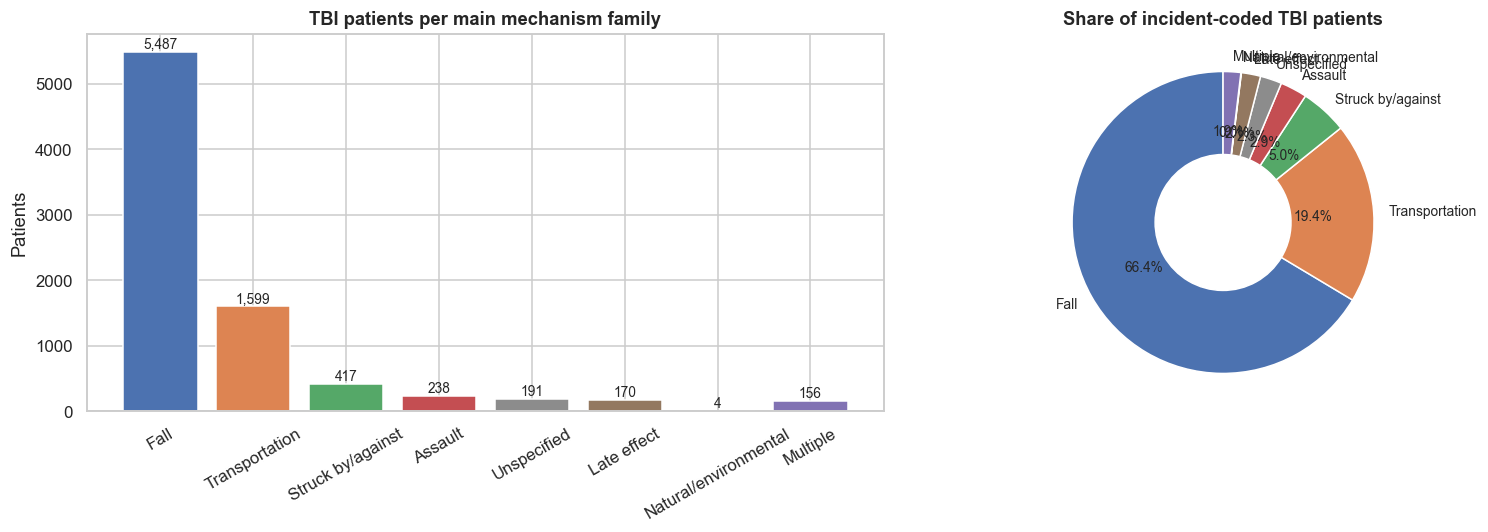


Multiple-category patients: 156
Family combinations:
main_set
Fall + Struck by/against                     36
Fall + Unspecified                           35
Fall + Transportation                        18
Fall + Late effect                           12
Assault + Struck by/against                  10
Fall + Natural/environmental                  9
Assault + Fall                                8
Struck by/against + Transportation            6
Transportation + Unspecified                  6
Late effect + Unspecified                     4
Late effect + Transportation                  4
Struck by/against + Unspecified               2
Assault + Late effect                         2
Natural/environmental + Struck by/against     1
Assault + Fall + Late effect                  1
Natural/environmental + Transportation        1
Late effect + Struck by/against               1


In [6]:
cat_df = df[df["main_category"].notna()].copy()
vc = cat_df["main_category"].value_counts().reindex(MAIN_CATS).fillna(0).astype(int)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
bars = ax[0].bar(vc.index, vc.values, color=[MAIN_COLORS[c] for c in vc.index])
ax[0].set_title("TBI patients per main mechanism family")
ax[0].set_ylabel("Patients")
ax[0].tick_params(axis="x", rotation=30)
for r, v in zip(bars, vc.values):
    ax[0].annotate(f"{int(v):,}", (r.get_x() + r.get_width()/2, v),
                   ha="center", va="bottom", fontsize=9)

ax[1].pie(vc.values, labels=vc.index, autopct="%1.1f%%", startangle=90,
          colors=[MAIN_COLORS[c] for c in vc.index],
          wedgeprops=dict(width=0.55), textprops={"fontsize": 9})
ax[1].set_title("Share of incident-coded TBI patients")
plt.tight_layout(); plt.show()

# breakdown of Multiple-category combinations
multi = cat_df[cat_df["main_category"] == "Multiple"]
combos = (multi["main_set"]
          .apply(lambda s: " + ".join(sorted(s)))
          .value_counts())
print(f"\nMultiple-category patients: {len(multi):,}")
print("Family combinations:")
print(combos.to_string())

## 5 · Subcategory distribution within each main family

For each of the seven main families we show the full subcategory distribution and a
**top 8–10 shortlist** that the downstream sections key off. Families with ≤ 8
subcategories show all of them.

A patient who has multiple distinct subcategories of the *same* family contributes
once to **each** of those subcategories (no double counting within one subcategory).

In [7]:
SEVEN = [c for c in MAIN_CATS if c != "Multiple"]

def patient_sub_counts(main_cat):
    counts = Counter()
    for _, r in cat_df.iterrows():
        seen = set()
        for fam, desc in r["sub_hits"]:
            if fam == main_cat and desc not in seen:
                counts[desc] += 1
                seen.add(desc)
    return pd.Series(counts).sort_values(ascending=False)


def pick_top(series, n_max=10, n_min=8, min_patients=3):
    s = series[series >= min_patients]
    if len(s) <= n_min:
        return s
    return s.head(min(n_max, len(s)))


SUB_DISTRIB = {c: patient_sub_counts(c) for c in SEVEN}
TOP_SUBS    = {c: pick_top(SUB_DISTRIB[c]) for c in SEVEN}

for c in SEVEN:
    s_all, s_top = SUB_DISTRIB[c], TOP_SUBS[c]
    n_unique_pats = (cat_df["sub_hits"]
                     .apply(lambda hs: any(m == c for m, _ in hs)).sum())
    total_hits = s_all.sum()
    top_share  = (s_top.sum() / total_hits) if total_hits else 0
    print(f"=== {c:<25} ===  unique patients in family: {n_unique_pats:,}  | "
          f"subs observed: {len(s_all):>3}  | top-{len(s_top)} hit share: {top_share*100:.1f}%")

=== Fall                      ===  unique patients in family: 5,606  | subs observed:  30  | top-10 hit share: 95.4%
=== Transportation            ===  unique patients in family: 1,634  | subs observed:  43  | top-10 hit share: 80.4%
=== Struck by/against         ===  unique patients in family: 473  | subs observed:  11  | top-10 hit share: 99.8%
=== Assault                   ===  unique patients in family: 259  | subs observed:   8  | top-8 hit share: 100.0%
=== Unspecified               ===  unique patients in family: 238  | subs observed:   2  | top-2 hit share: 100.0%
=== Late effect               ===  unique patients in family: 194  | subs observed:   5  | top-2 hit share: 97.9%
=== Natural/environmental     ===  unique patients in family: 15  | subs observed:   7  | top-2 hit share: 53.3%


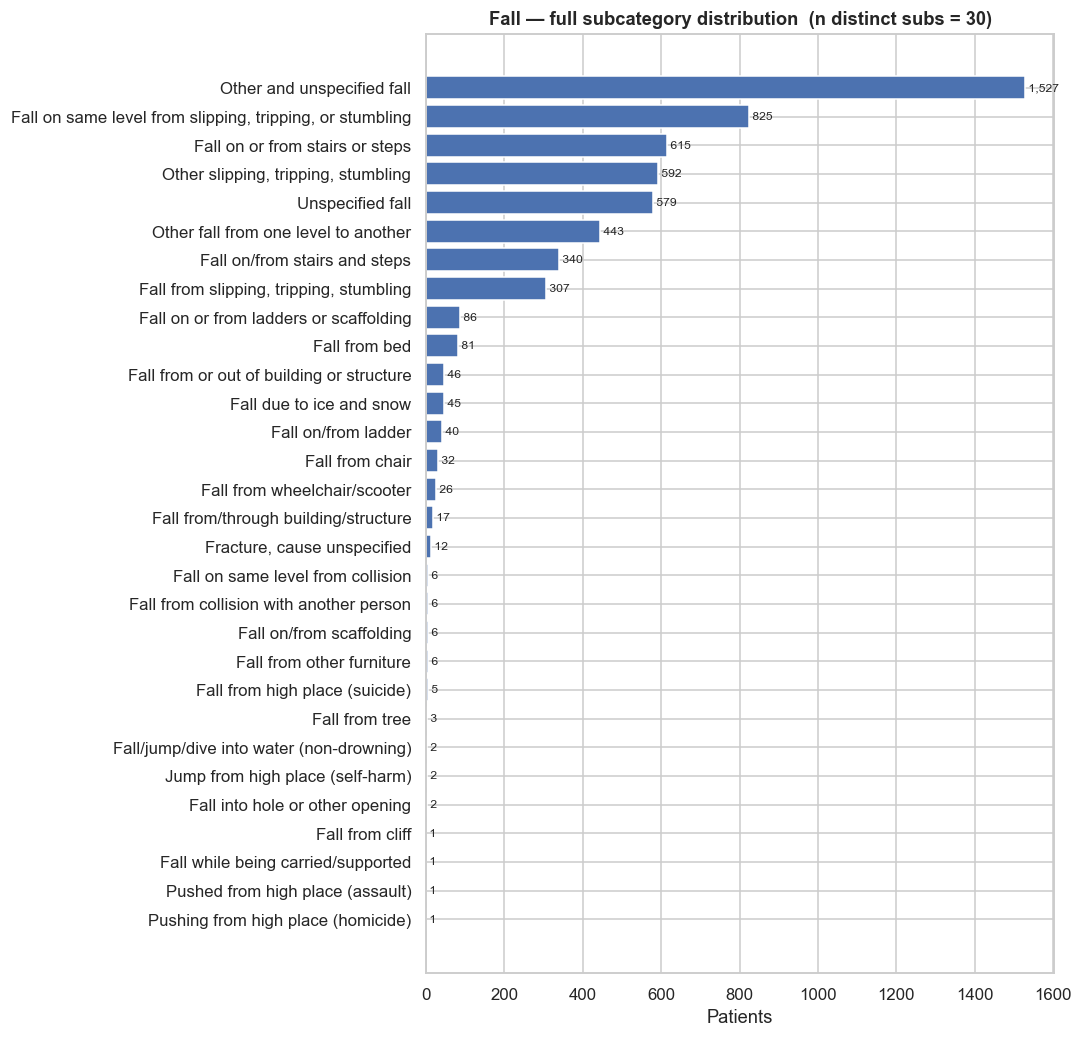

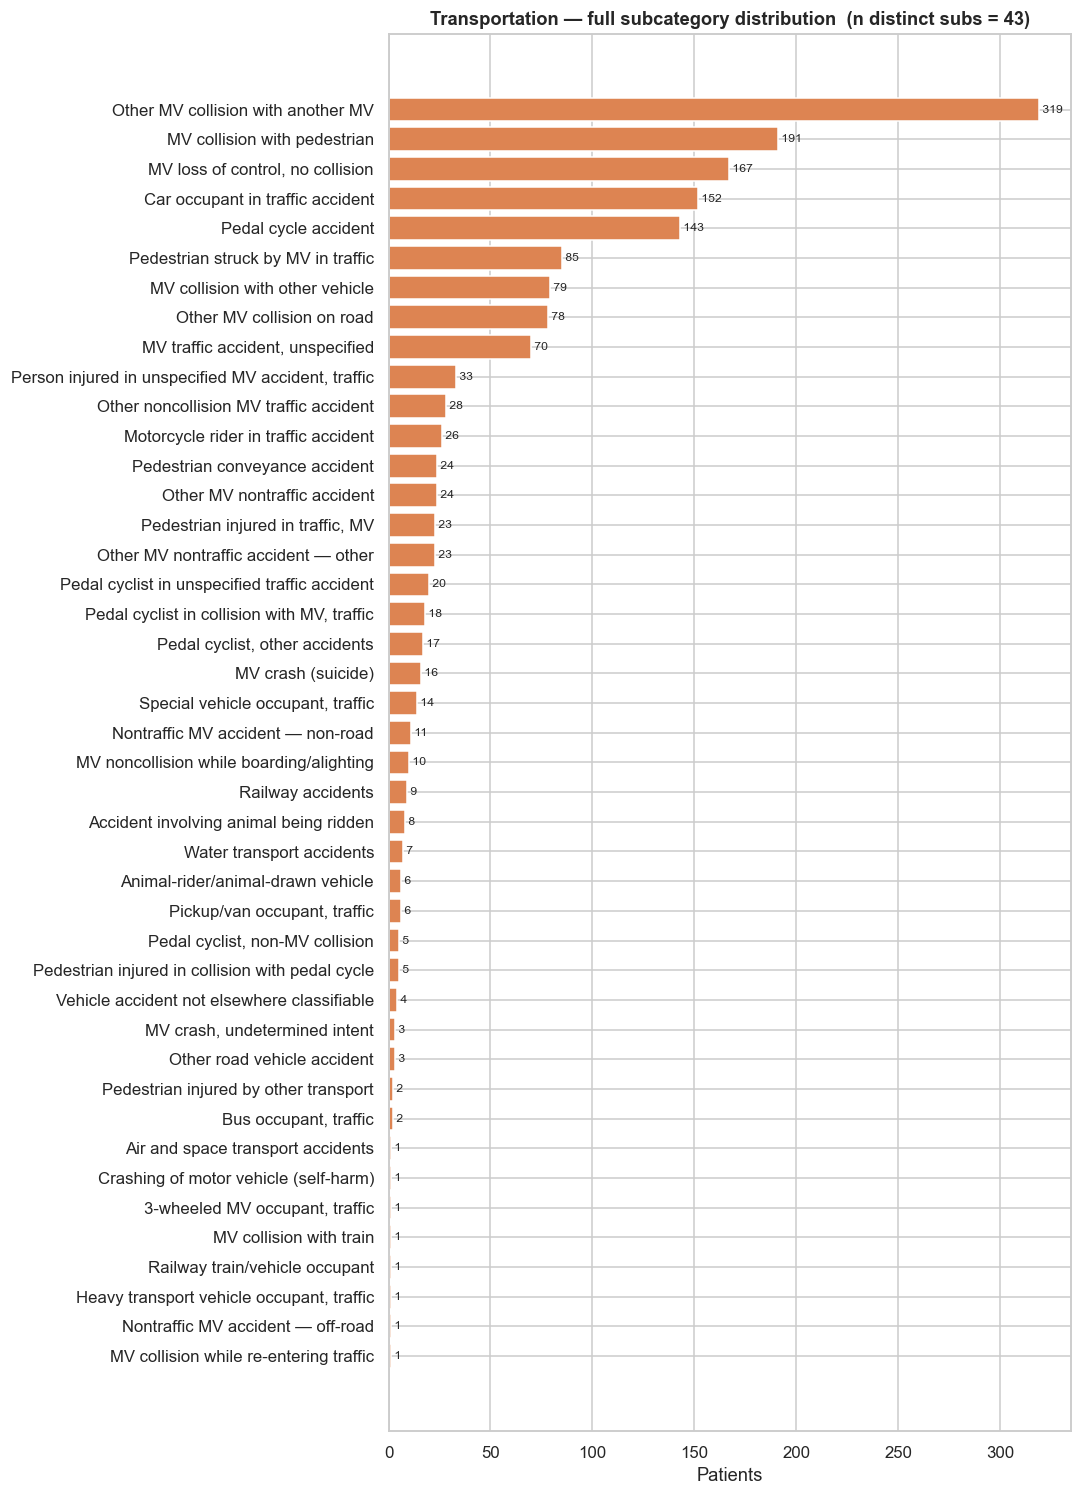

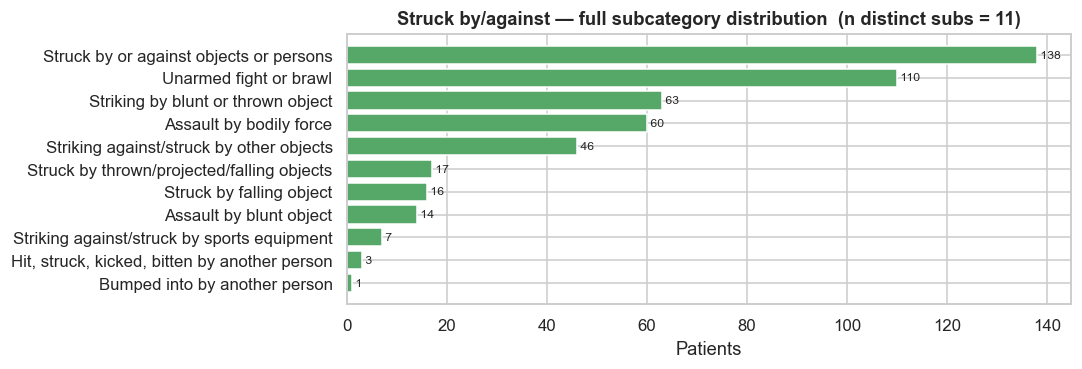

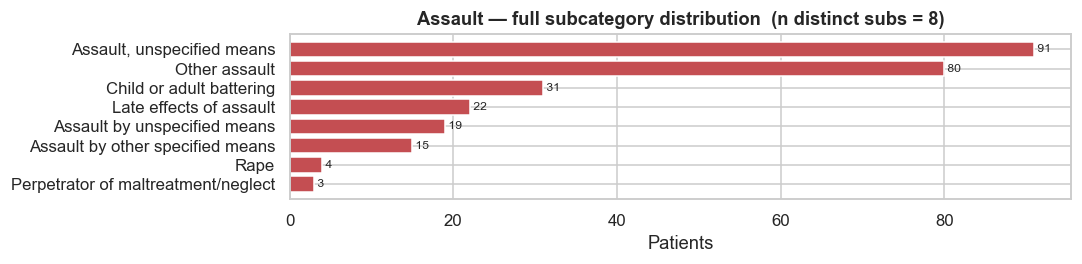

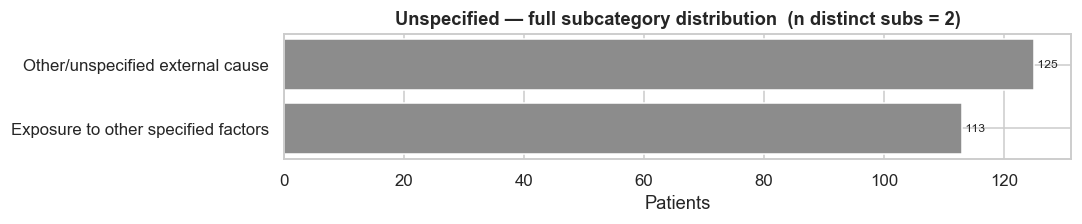

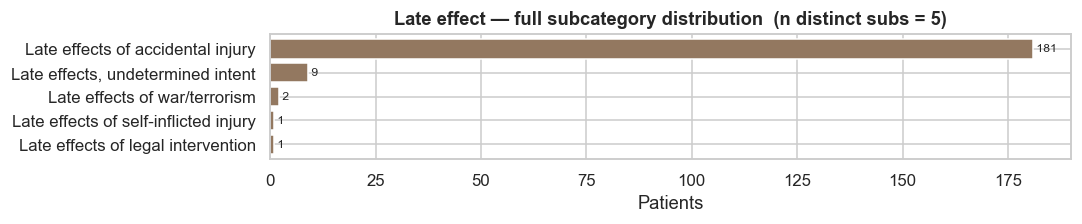

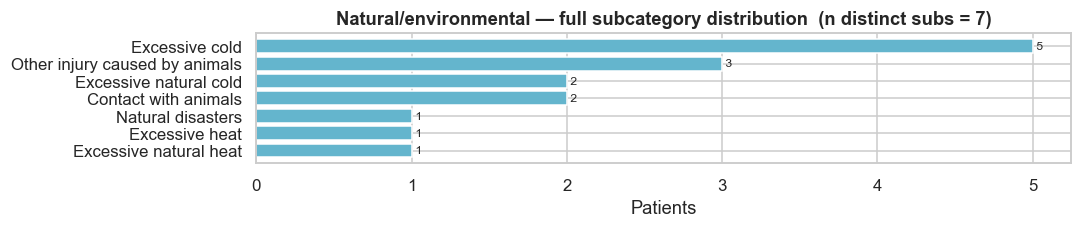

In [8]:
# full subcategory distribution per family
for c in SEVEN:
    s = SUB_DISTRIB[c]
    if s.empty:
        print(f"No subcategories observed for {c}.")
        continue
    fig, ax = plt.subplots(figsize=(10, max(2.2, 0.32 * len(s))))
    ax.barh(s.index[::-1], s.values[::-1], color=MAIN_COLORS[c])
    ax.set_title(f"{c} — full subcategory distribution  (n distinct subs = {len(s)})")
    ax.set_xlabel("Patients")
    for i, v in enumerate(s.values[::-1]):
        ax.annotate(f" {int(v):,}", (v, i), va="center", fontsize=8)
    plt.tight_layout(); plt.show()

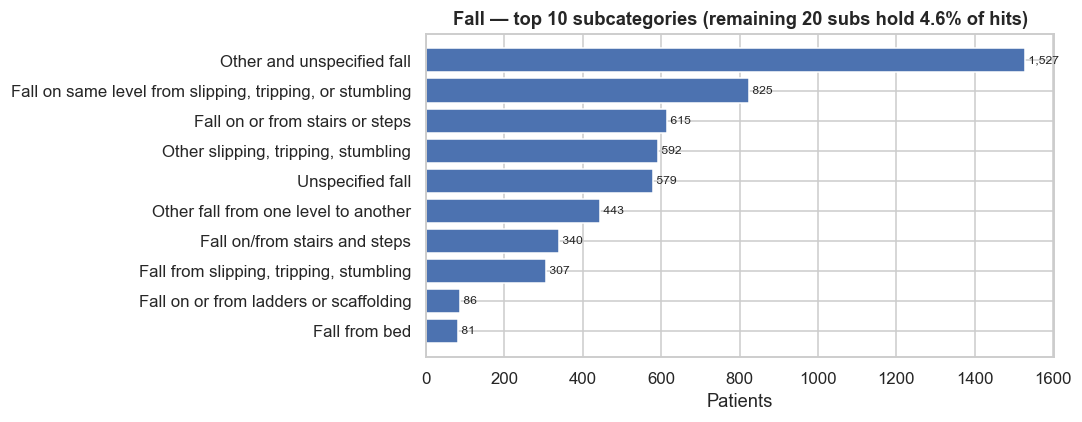

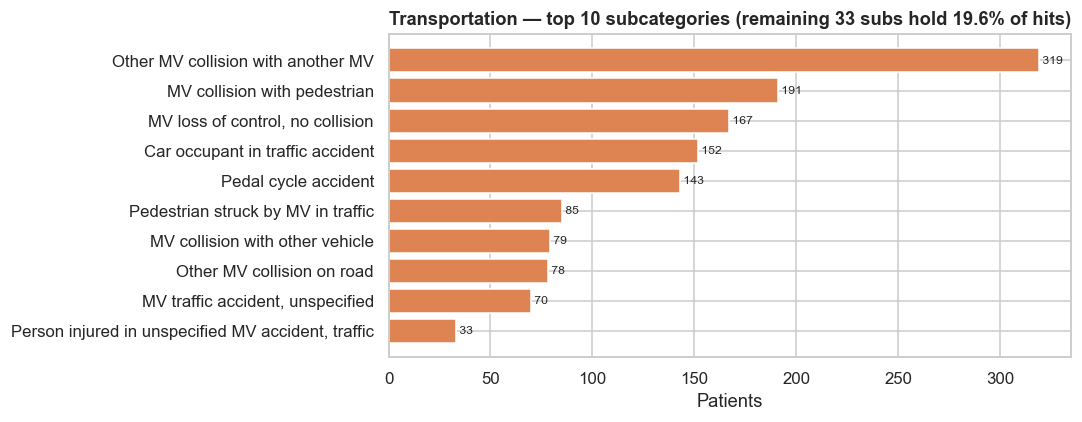

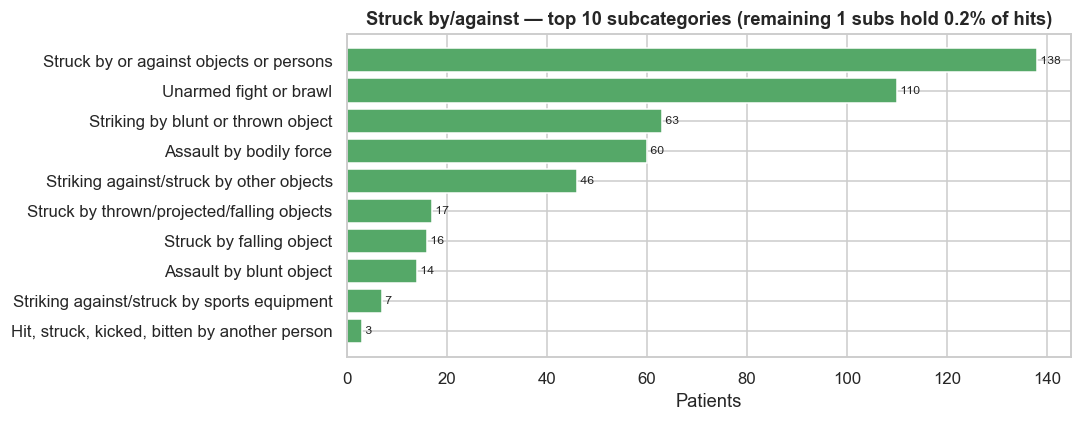

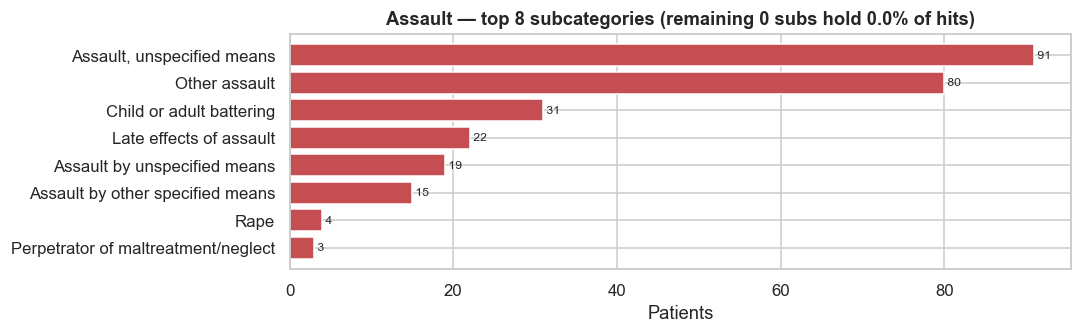

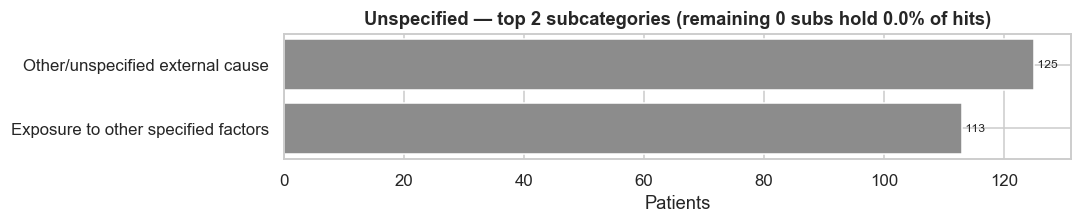

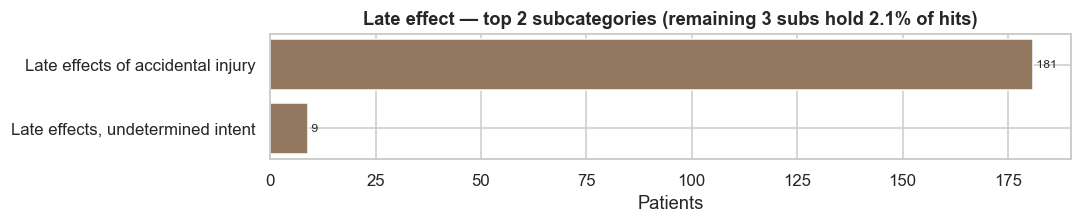

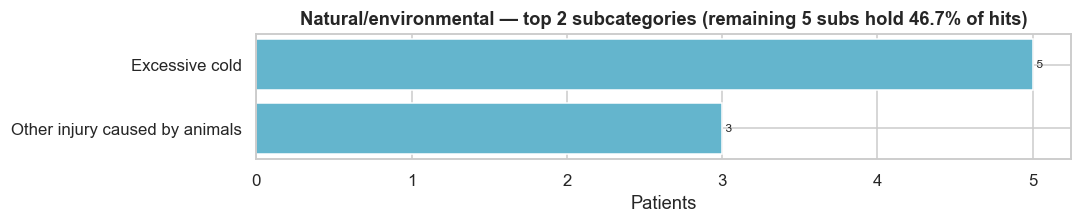

In [9]:
# top-N shortlists carried forward
for c in SEVEN:
    s_all, s_top = SUB_DISTRIB[c], TOP_SUBS[c]
    if s_top.empty:
        continue
    total = s_all.sum()
    tail  = total - s_top.sum()
    fig, ax = plt.subplots(figsize=(10, max(2.2, 0.4 * len(s_top))))
    ax.barh(s_top.index[::-1], s_top.values[::-1], color=MAIN_COLORS[c])
    ax.set_title(f"{c} — top {len(s_top)} subcategories "
                 f"(remaining {len(s_all)-len(s_top)} subs hold "
                 f"{(tail/total*100) if total else 0:.1f}% of hits)")
    ax.set_xlabel("Patients")
    for i, v in enumerate(s_top.values[::-1]):
        ax.annotate(f" {int(v):,}", (v, i), va="center", fontsize=8)
    plt.tight_layout(); plt.show()

### Tail-coverage check

`tail_share_%` is the fraction of subcategory hits *not* captured by the top-N
shortlist. **>20% = wide tail** — consider widening the shortlist in section 5 by
raising `n_max`.

In [10]:
tail_report = []
for c in SEVEN:
    s_all, s_top = SUB_DISTRIB[c], TOP_SUBS[c]
    total = s_all.sum()
    tail  = total - s_top.sum()
    tail_report.append({
        "main_category": c,
        "n_subs_total":  len(s_all),
        "n_subs_top":    len(s_top),
        "top_share_%":   round(s_top.sum() / total * 100, 1) if total else 0,
        "tail_share_%":  round(tail / total * 100, 1) if total else 0,
        "flag":          "⚠️ wide tail" if total and tail/total > 0.20 else "ok",
    })
pd.DataFrame(tail_report)

,main_category,n_subs_total,n_subs_top,top_share_%,tail_share_%,flag
0,Fall,30,10,95.4,4.6,ok
1,Transportation,43,10,80.4,19.6,ok
2,Struck by/against,11,10,99.8,0.2,ok
3,Assault,8,8,100.0,0.0,ok
4,Unspecified,2,2,100.0,0.0,ok
5,Late effect,5,2,97.9,2.1,ok
6,Natural/environmental,7,2,53.3,46.7,⚠️ wide tail


## 6 · Discharge-location buckets

Raw `discharge_location` reclassified into **Home, Home Health Care, Skilled Nursing
Facility, Long-Term Care Facility, Hospice, Dead/Expired, Other**. `Dead/Expired`
also catches rows with `hospital_expire_flag == 1` whose location was something else.

In [11]:
def discharge_bucket(row):
    if row["hospital_expire_flag"] == 1:
        return "Dead/Expired"
    loc = row["discharge_location"]
    if pd.isna(loc):
        return np.nan
    loc = str(loc).strip().upper()
    if loc == "HOME":                          return "Home"
    if loc == "HOME HEALTH CARE":              return "Home Health Care"
    if loc == "SKILLED NURSING FACILITY":      return "Skilled Nursing Facility"
    if loc == "CHRONIC/LONG TERM ACUTE CARE":  return "Long-Term Care Facility"
    if loc == "HOSPICE":                       return "Hospice"
    if loc == "DIED":                          return "Dead/Expired"
    return "Other"

df["discharge_bucket"]     = df.apply(discharge_bucket, axis=1)
cat_df["discharge_bucket"] = df.loc[cat_df.index, "discharge_bucket"]

print("Discharge-bucket counts (whole cohort):")
print(df["discharge_bucket"].value_counts(dropna=False).to_string())

Discharge-bucket counts (whole cohort):
discharge_bucket
Home                        2580
NaN                         2543
Skilled Nursing Facility    1343
Other                       1303
Home Health Care            1084
Dead/Expired                 545
Long-Term Care Facility      216
Hospice                      109


In [12]:
# what raw discharge_location values land in 'Other'
other_raw = (df.loc[df["discharge_bucket"] == "Other", "discharge_location"]
               .fillna("(missing)").value_counts())
print("Raw discharge_location values mapped to 'Other':")
print(other_raw.to_string())

Raw discharge_location values mapped to 'Other':
discharge_location
REHAB                  1067
AGAINST ADVICE           70
OTHER FACILITY           49
PSYCH FACILITY           47
ACUTE HOSPITAL           45
ASSISTED LIVING          22
HEALTHCARE FACILITY       3


### 6a · Discharge distribution by **main family**

Incident-coded patients with a recorded discharge_location: 6,219  (dropped 2,043 with missing discharge_location)


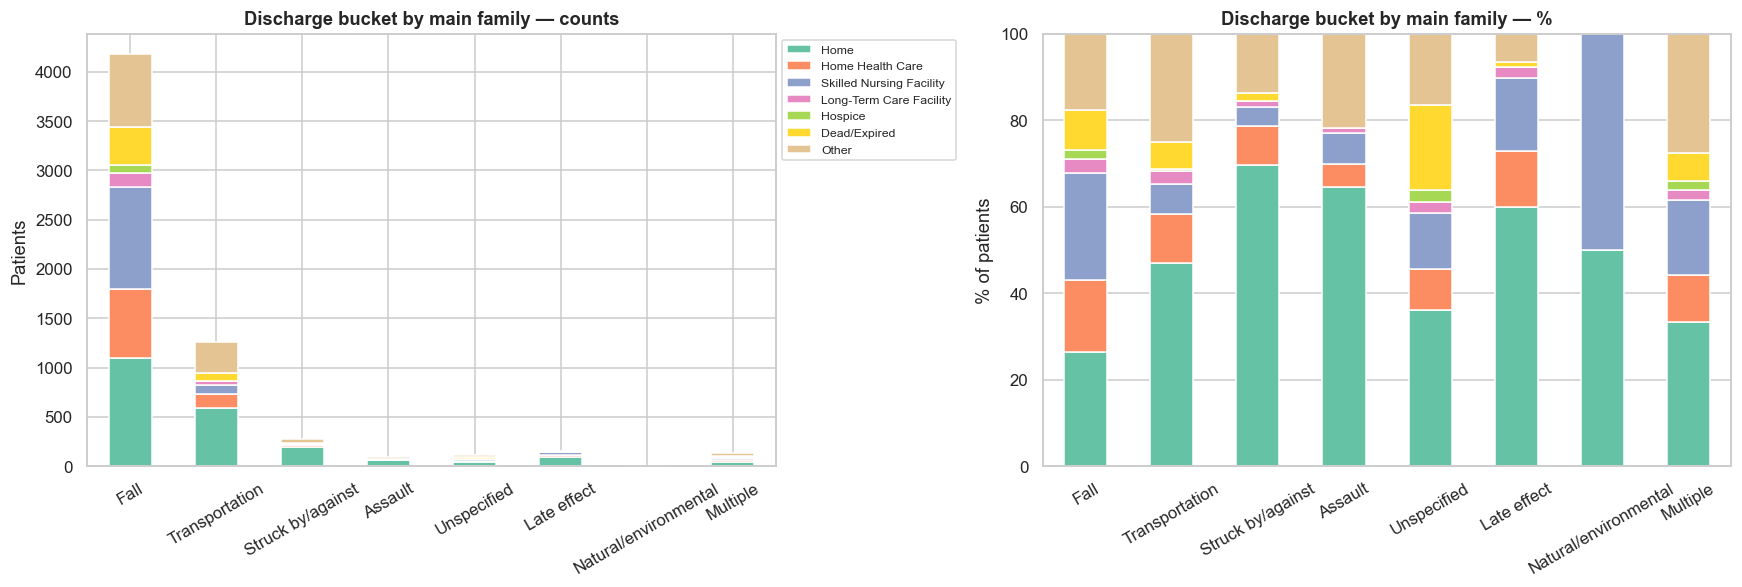

discharge_bucket,Home,Home Health Care,Skilled Nursing Facility,Long-Term Care Facility,Hospice,Dead/Expired,Other
main_category,,,,,,,
Fall,1099,695,1034,143,83,388,735
Transportation,591,144,86,38,6,79,314
Struck by/against,193,25,12,4,0,5,38
Assault,62,5,7,1,0,0,21
Unspecified,42,11,15,3,3,23,19
Late effect,93,20,26,4,0,2,10
Natural/environmental,1,0,1,0,0,0,0
Multiple,46,15,24,3,3,9,38


In [13]:
dd = cat_df.dropna(subset=["discharge_bucket"]).copy()
n_no_disch = cat_df["discharge_bucket"].isna().sum()
print(f"Incident-coded patients with a recorded discharge_location: {len(dd):,}  "
      f"(dropped {n_no_disch:,} with missing discharge_location)")

ct = (pd.crosstab(dd["main_category"], dd["discharge_bucket"])
        .reindex(index=MAIN_CATS, columns=DISCH_ORDER, fill_value=0))
ct_pct = ct.div(ct.sum(axis=1).replace(0, np.nan), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
ct.plot(kind="bar", stacked=True, ax=axes[0],
        color=[DISCH_COLORS[d] for d in DISCH_ORDER])
axes[0].set_title("Discharge bucket by main family — counts")
axes[0].set_ylabel("Patients"); axes[0].set_xlabel("")
axes[0].legend(loc="upper left", bbox_to_anchor=(1.0, 1.0), fontsize=8)
axes[0].tick_params(axis="x", rotation=30)

ct_pct.plot(kind="bar", stacked=True, ax=axes[1],
            color=[DISCH_COLORS[d] for d in DISCH_ORDER], legend=False)
axes[1].set_title("Discharge bucket by main family — %")
axes[1].set_ylabel("% of patients"); axes[1].set_xlabel("")
axes[1].set_ylim(0, 100); axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()
ct

### 6b · Discharge distribution by **top subcategories** (one chart per family)

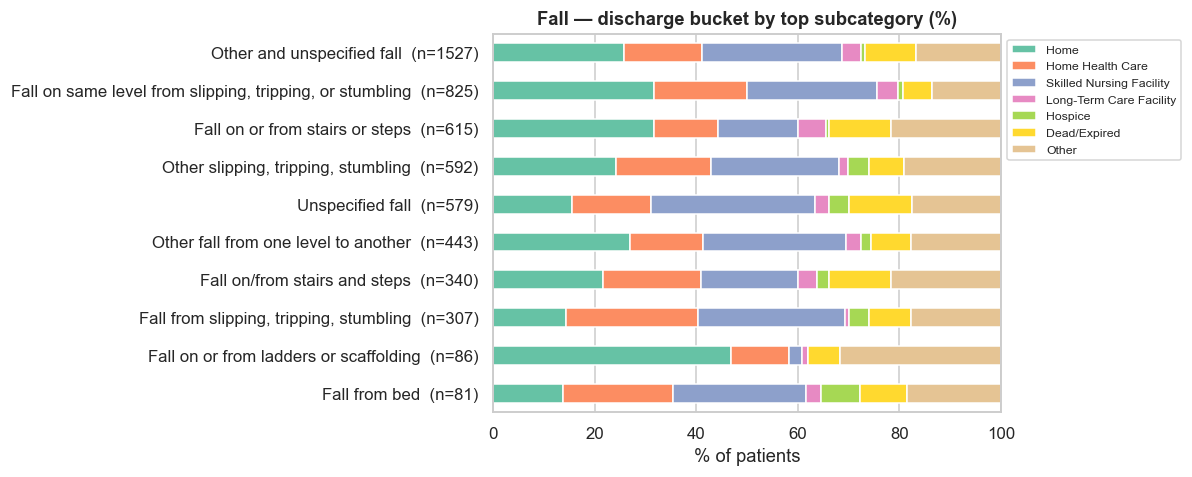

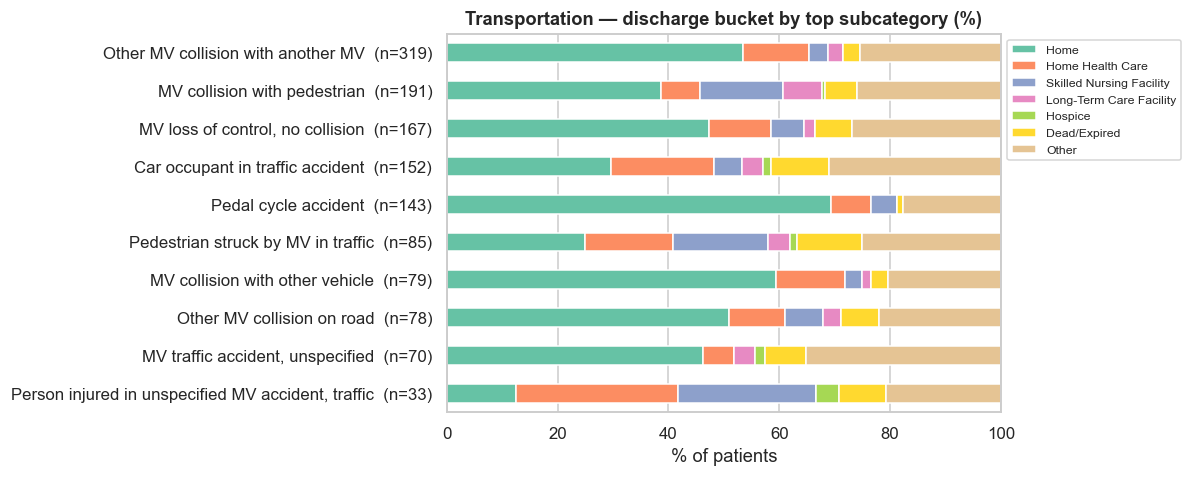

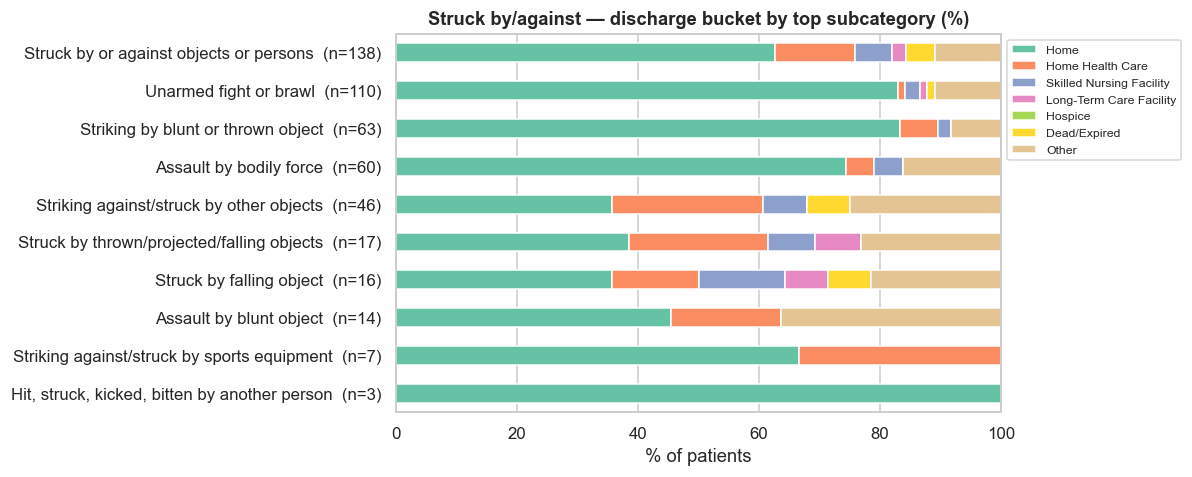

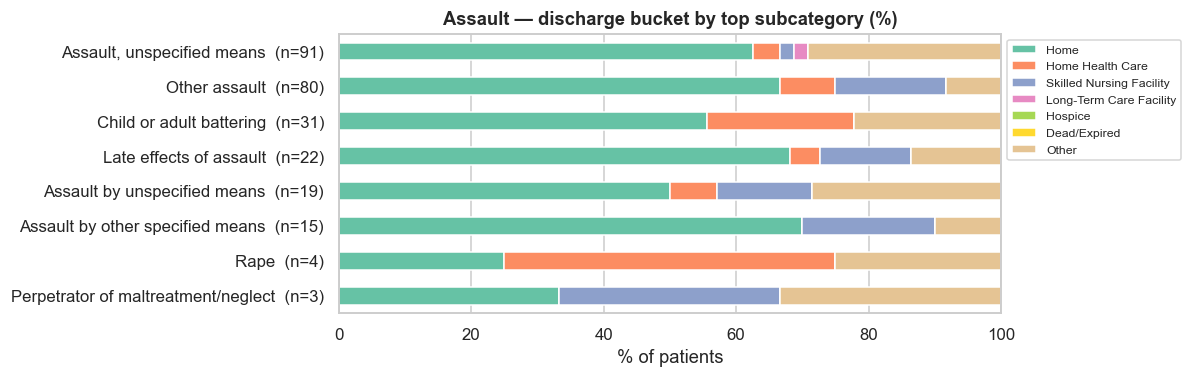

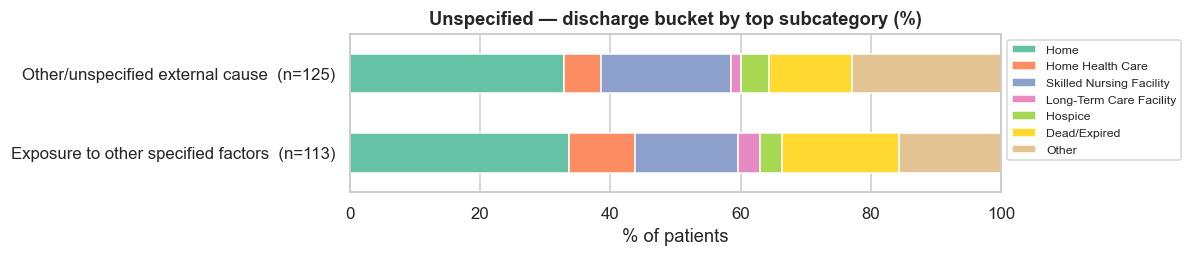

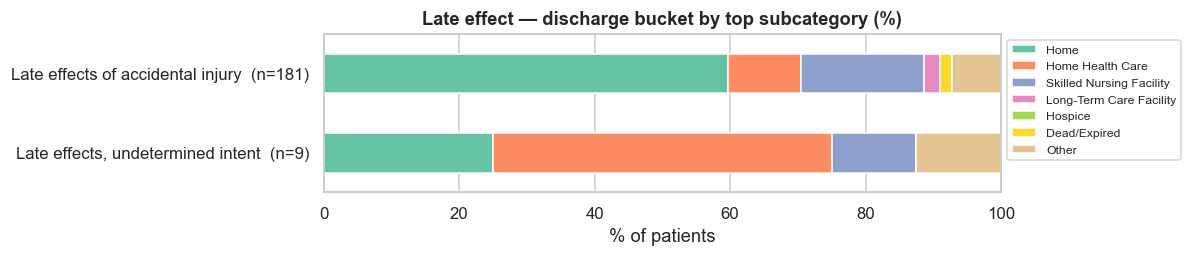

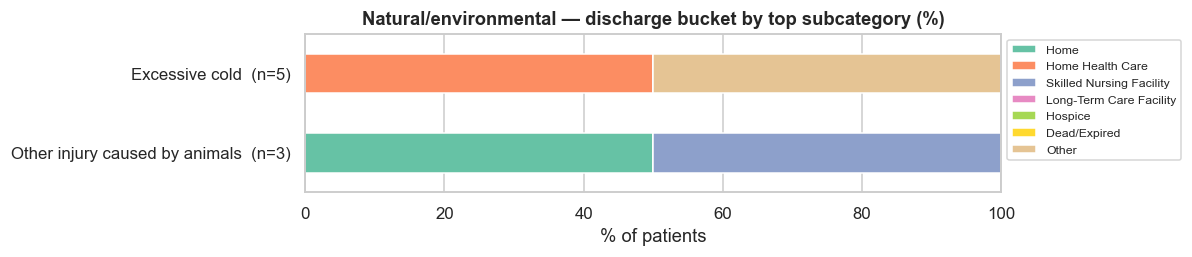

In [14]:
def patients_in_subs(main_cat, top_subs):
    for sub in list(top_subs.index):
        mask = cat_df["sub_hits"].apply(
            lambda hs: any(m == main_cat and d == sub for m, d in hs))
        yield sub, cat_df[mask]

for c in SEVEN:
    if TOP_SUBS[c].empty:
        continue
    rows = []
    for sub, slice_df in patients_in_subs(c, TOP_SUBS[c]):
        s = slice_df["discharge_bucket"].value_counts().reindex(DISCH_ORDER, fill_value=0)
        s.name = f"{sub}  (n={len(slice_df)})"
        rows.append(s)
    ct = pd.DataFrame(rows)
    ct_pct = ct.div(ct.sum(axis=1).replace(0, np.nan), axis=0) * 100
    fig, ax = plt.subplots(figsize=(11, max(2.5, 0.45 * len(ct))))
    ct_pct.plot(kind="barh", stacked=True, ax=ax,
                color=[DISCH_COLORS[d] for d in DISCH_ORDER])
    ax.set_title(f"{c} — discharge bucket by top subcategory (%)")
    ax.set_xlabel("% of patients"); ax.set_xlim(0, 100)
    ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0), fontsize=8)
    ax.invert_yaxis()
    plt.tight_layout(); plt.show()

## 7 · Length of stay (Hospital and ICU)

LOS distributions have a heavy right tail. We use **log axes** (log-Y for histograms,
log-X for KDE/boxplots) instead of `.clip()` so the bulk *and* the tail stay visible.

In [15]:
neg = (df["hospital_los_days"] < 0).sum()
los_all = df[df["hospital_los_days"] > 0].copy()
icu_all = df[df["icu_los_days"]  > 0].copy()
print(f"Hospital LOS ≤ 0 dropped: {neg + (df['hospital_los_days']==0).sum()}")
print(f"Patients with valid hospital LOS : {len(los_all):,}")
print(f"Patients with an ICU stay (>0)   : {len(icu_all):,} "
      f"({len(icu_all)/len(df)*100:.1f}% of cohort)")

Hospital LOS ≤ 0 dropped: 16
Patients with valid hospital LOS : 9,707
Patients with an ICU stay (>0)   : 3,624 (37.3% of cohort)


### 7a · LOS by **main family**

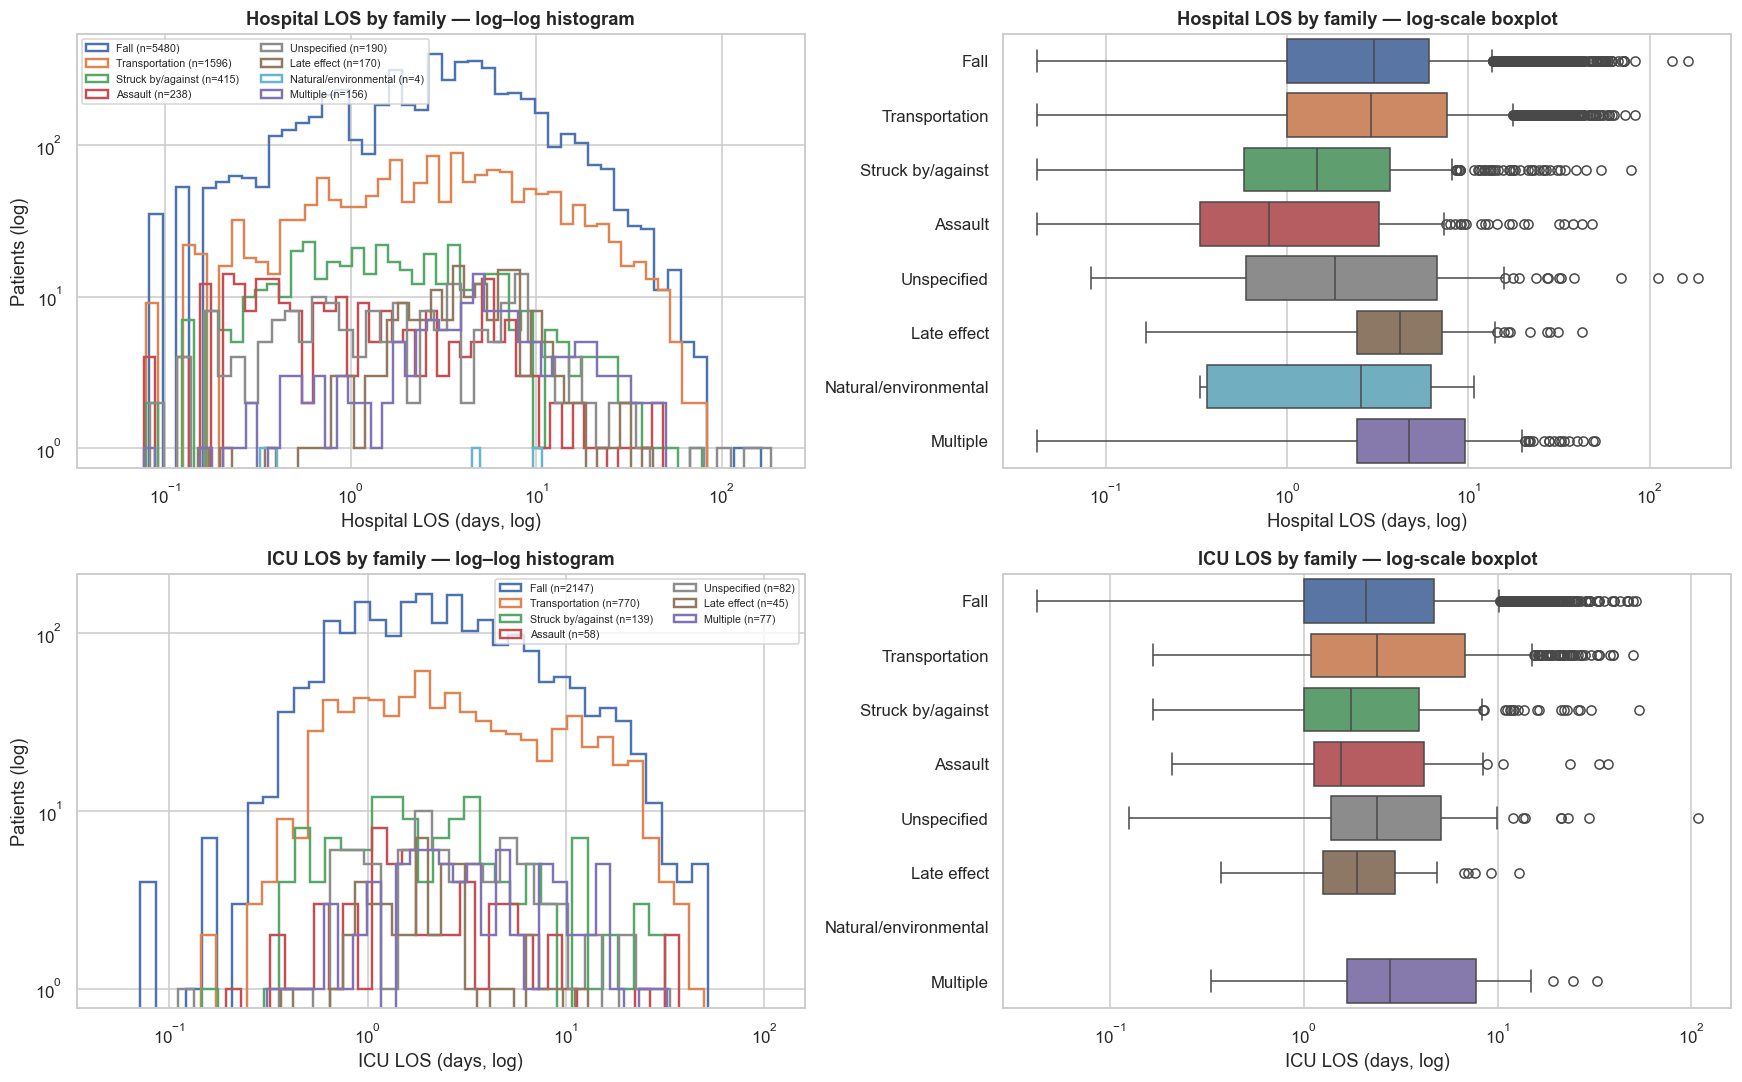

Hospital LOS (days) by main family:
                            n  median    p90     max
main_category                                       
Fall                   5480.0    3.00  12.08  161.54
Transportation         1596.0    2.92  17.44   82.92
Struck by/against       415.0    1.46   8.58   78.54
Assault                 238.0    0.79   6.92   48.25
Unspecified             190.0    1.83  12.05  184.92
Late effect             170.0    4.19  10.72   42.42
Natural/environmental     4.0    2.56   8.95   10.75
Multiple                156.0    4.73  20.94   49.67

ICU LOS (days) by main family:
                            n  median    p90     max
main_category                                       
Fall                   2147.0    2.08   9.81   51.88
Transportation          770.0    2.38  14.55   49.88
Struck by/against       139.0    1.75  11.65   53.88
Assault                  58.0    1.56   8.14   37.25
Unspecified              82.0    2.40   9.95  108.79
Late effect              45.0  

In [16]:
los_cat = los_all[los_all["main_category"].notna()].copy()
icu_cat = icu_all[icu_all["main_category"].notna()].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# (1) Hospital LOS log–log histogram
for c in MAIN_CATS:
    d = los_cat.loc[los_cat["main_category"] == c, "hospital_los_days"]
    if len(d) == 0: continue
    axes[0, 0].hist(d, bins=np.logspace(np.log10(0.05), np.log10(d.max()), 50),
                    histtype="step", linewidth=1.6, label=f"{c} (n={len(d)})",
                    color=MAIN_COLORS[c])
axes[0, 0].set_xscale("log"); axes[0, 0].set_yscale("log")
axes[0, 0].set_title("Hospital LOS by family — log–log histogram")
axes[0, 0].set_xlabel("Hospital LOS (days, log)"); axes[0, 0].set_ylabel("Patients (log)")
axes[0, 0].legend(fontsize=7, ncol=2)

# (2) Hospital LOS boxplot, log-X
sns.boxplot(data=los_cat, y="main_category", x="hospital_los_days",
            order=MAIN_CATS, ax=axes[0, 1],
            palette=[MAIN_COLORS[c] for c in MAIN_CATS])
axes[0, 1].set_xscale("log")
axes[0, 1].set_title("Hospital LOS by family — log-scale boxplot")
axes[0, 1].set_xlabel("Hospital LOS (days, log)"); axes[0, 1].set_ylabel("")

# (3) ICU LOS log–log histogram
for c in MAIN_CATS:
    d = icu_cat.loc[icu_cat["main_category"] == c, "icu_los_days"]
    if len(d) == 0: continue
    axes[1, 0].hist(d, bins=np.logspace(np.log10(0.05), np.log10(d.max()), 40),
                    histtype="step", linewidth=1.6, label=f"{c} (n={len(d)})",
                    color=MAIN_COLORS[c])
axes[1, 0].set_xscale("log"); axes[1, 0].set_yscale("log")
axes[1, 0].set_title("ICU LOS by family — log–log histogram")
axes[1, 0].set_xlabel("ICU LOS (days, log)"); axes[1, 0].set_ylabel("Patients (log)")
axes[1, 0].legend(fontsize=7, ncol=2)

# (4) ICU LOS boxplot, log-X
sns.boxplot(data=icu_cat, y="main_category", x="icu_los_days",
            order=MAIN_CATS, ax=axes[1, 1],
            palette=[MAIN_COLORS[c] for c in MAIN_CATS])
axes[1, 1].set_xscale("log")
axes[1, 1].set_title("ICU LOS by family — log-scale boxplot")
axes[1, 1].set_xlabel("ICU LOS (days, log)"); axes[1, 1].set_ylabel("")

plt.tight_layout(); plt.show()

def los_stats(g, col):
    return pd.Series({"n": len(g),
                      "median": round(g[col].median(), 2),
                      "p90":    round(g[col].quantile(0.90), 2),
                      "max":    round(g[col].max(), 2)})
print("Hospital LOS (days) by main family:")
print(los_cat.groupby("main_category").apply(lambda g: los_stats(g, "hospital_los_days"))
        .reindex(MAIN_CATS))
print("\nICU LOS (days) by main family:")
print(icu_cat.groupby("main_category").apply(lambda g: los_stats(g, "icu_los_days"))
        .reindex(MAIN_CATS))

### 7b · LOS by **top subcategories**

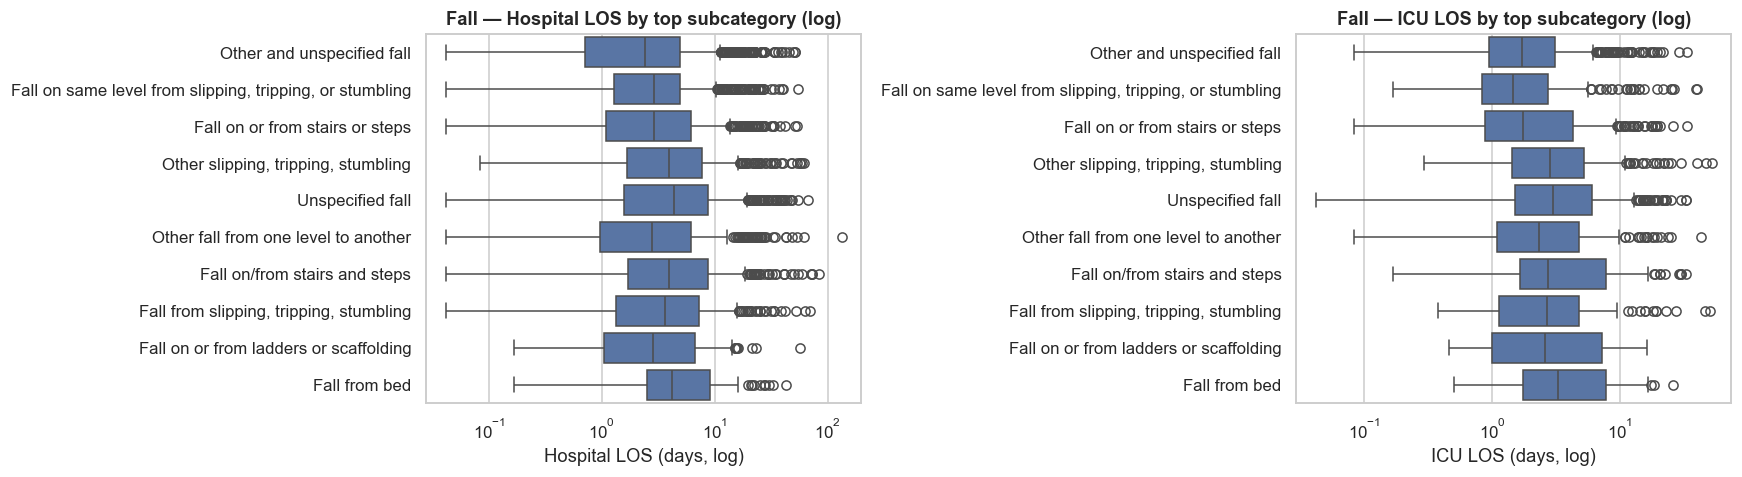

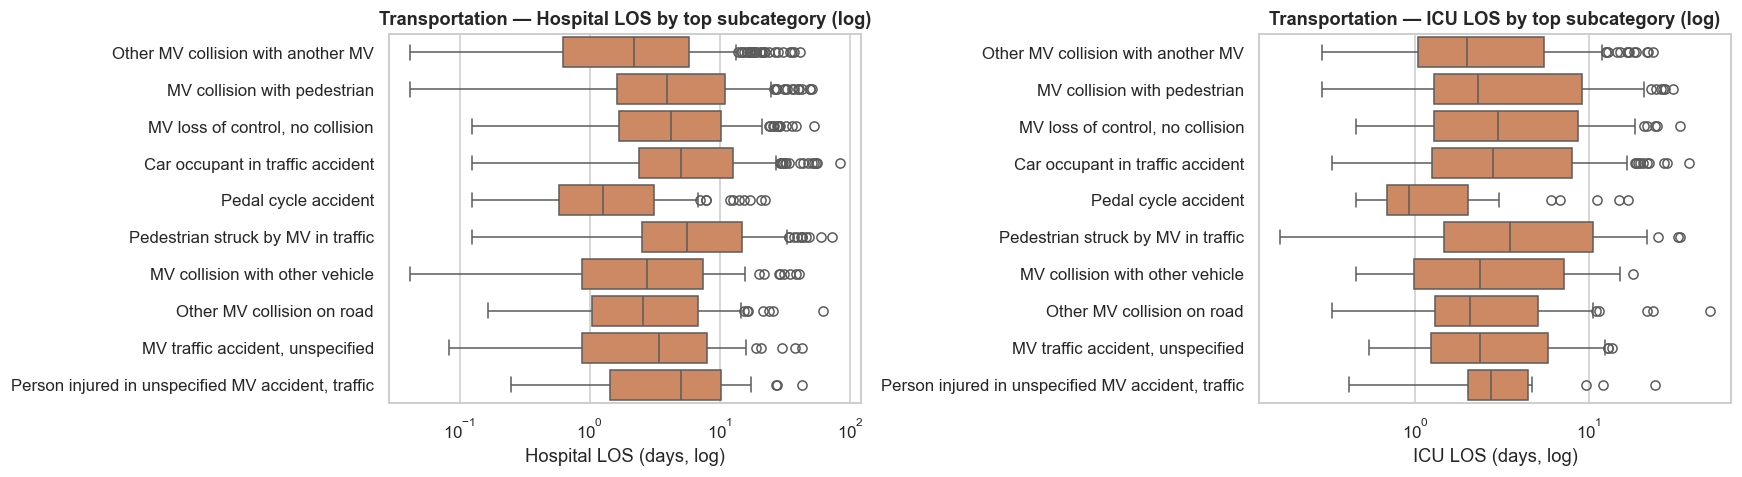

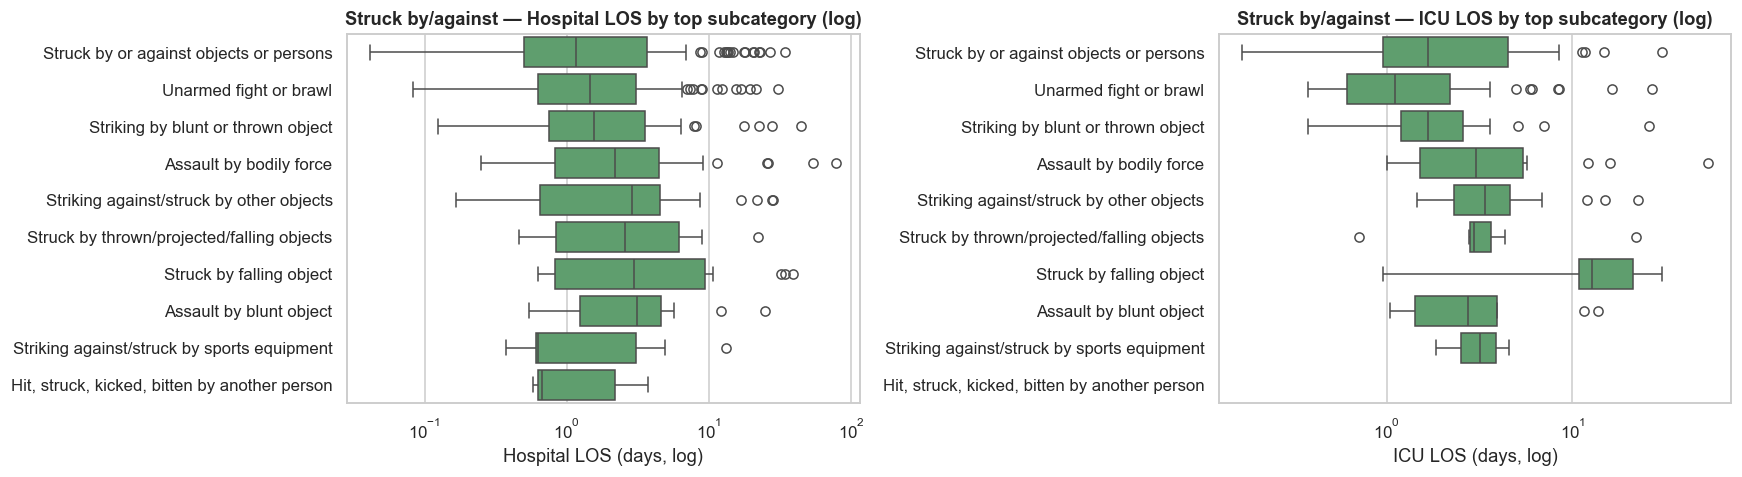

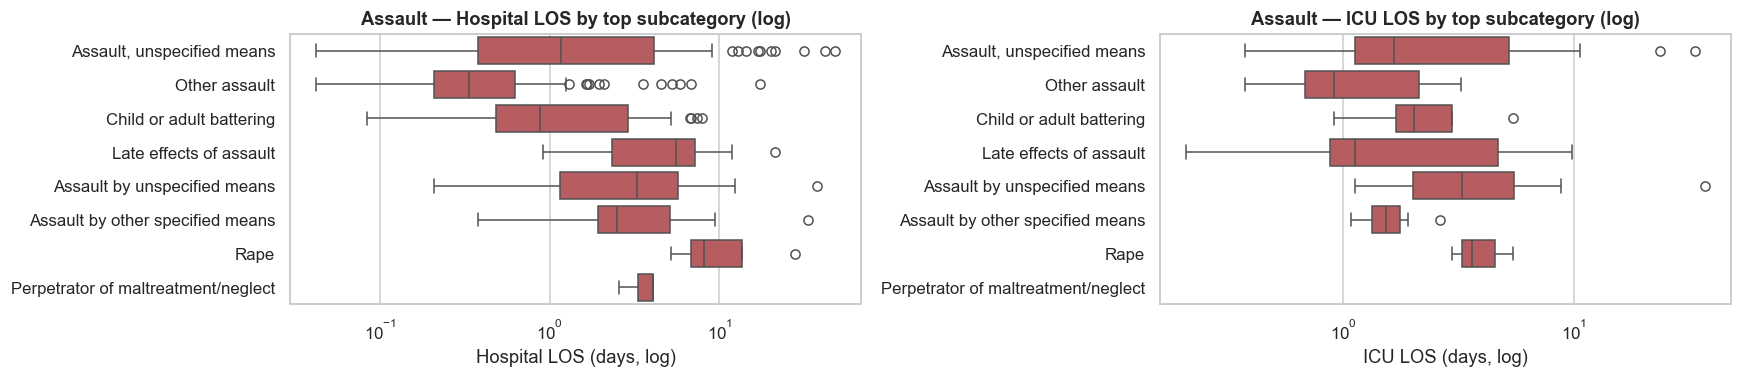

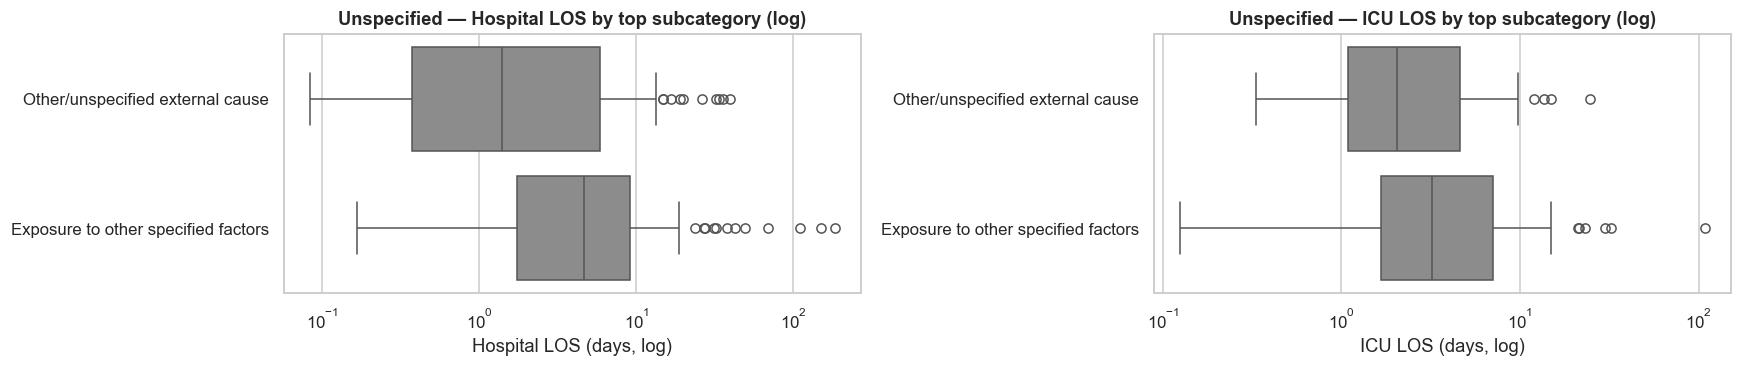

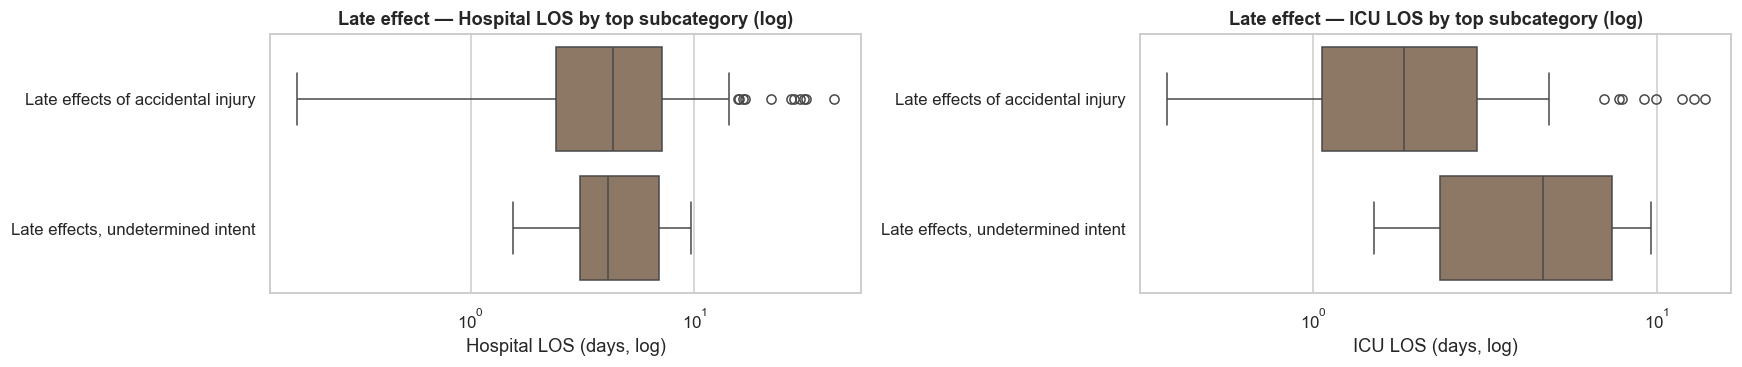

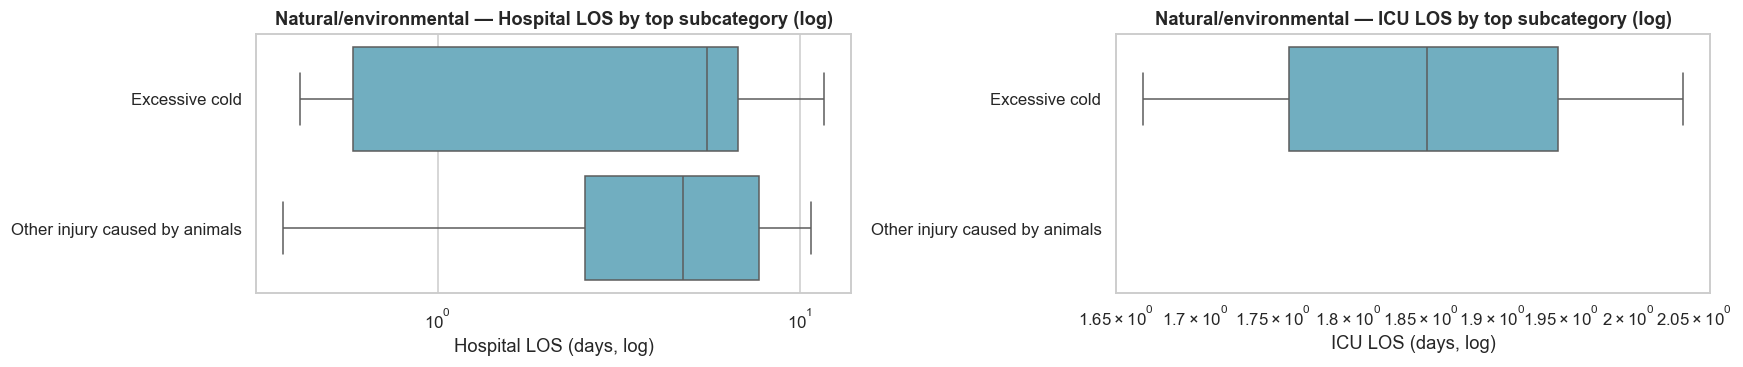

In [17]:
def los_long(top_subs, main_cat, los_col):
    out = []
    for sub, slice_df in patients_in_subs(main_cat, top_subs):
        vals = slice_df[los_col].dropna()
        vals = vals[vals > 0]
        for v in vals:
            out.append({"subcategory": sub, "value": v})
    return pd.DataFrame(out)

for c in SEVEN:
    if TOP_SUBS[c].empty:
        continue
    long_h = los_long(TOP_SUBS[c], c, "hospital_los_days")
    long_i = los_long(TOP_SUBS[c], c, "icu_los_days")
    if long_h.empty and long_i.empty:
        continue
    fig, axes = plt.subplots(1, 2, figsize=(16, max(3.5, 0.45 * len(TOP_SUBS[c]))))
    if not long_h.empty:
        sns.boxplot(data=long_h, y="subcategory", x="value", ax=axes[0],
                    order=list(TOP_SUBS[c].index), color=MAIN_COLORS[c])
        axes[0].set_xscale("log")
        axes[0].set_title(f"{c} — Hospital LOS by top subcategory (log)")
        axes[0].set_xlabel("Hospital LOS (days, log)"); axes[0].set_ylabel("")
    else:
        axes[0].set_visible(False)
    if not long_i.empty:
        sns.boxplot(data=long_i, y="subcategory", x="value", ax=axes[1],
                    order=list(TOP_SUBS[c].index), color=MAIN_COLORS[c])
        axes[1].set_xscale("log")
        axes[1].set_title(f"{c} — ICU LOS by top subcategory (log)")
        axes[1].set_xlabel("ICU LOS (days, log)"); axes[1].set_ylabel("")
    else:
        axes[1].set_visible(False)
    plt.tight_layout(); plt.show()

## 8 · Age and GCS by family / subcategory

### 8a · By **main family**

Patients with age : 8,262
Patients with GCS : 3,314


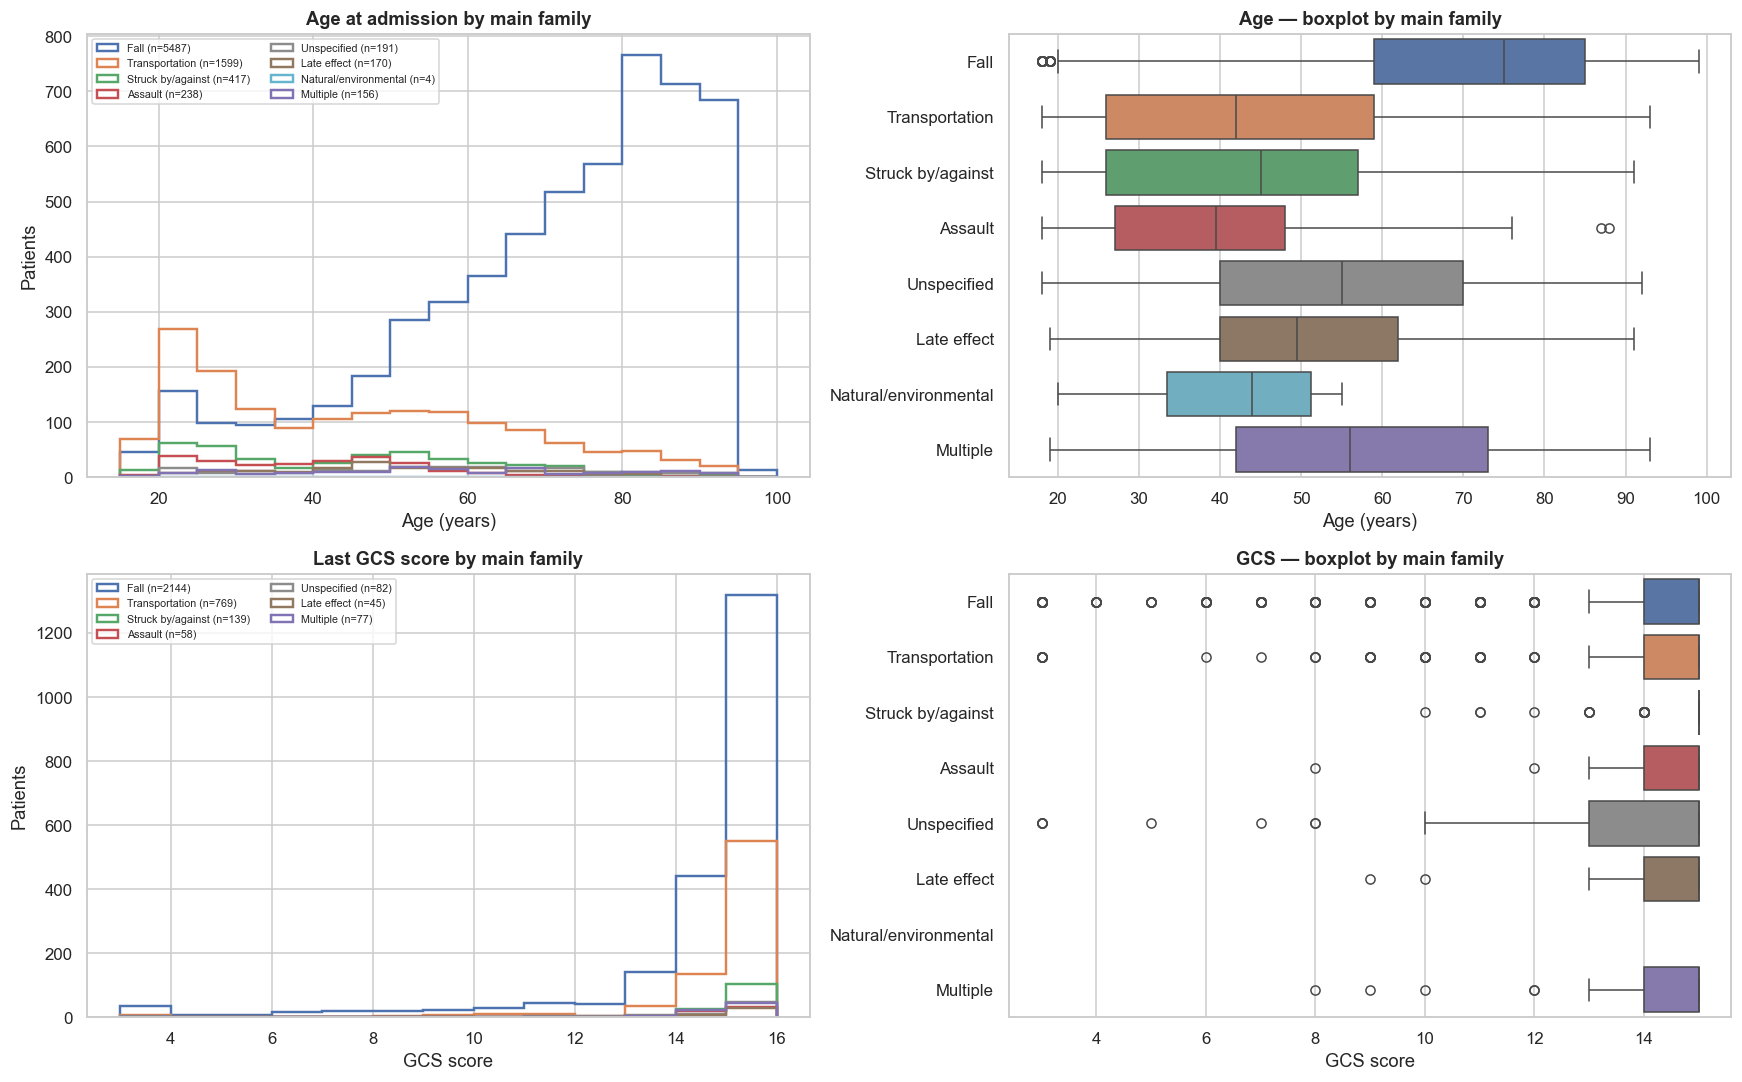


Age summary by main family:
                          n  median  mean   p25    p75
main_category                                         
Fall                   5487    75.0  69.8  59.0  85.00
Transportation         1599    42.0  44.5  26.0  59.00
Struck by/against       417    45.0  44.0  26.0  57.00
Assault                 238    39.5  39.4  27.0  48.00
Unspecified             191    55.0  54.4  40.0  70.00
Late effect             170    49.5  50.8  40.0  62.00
Natural/environmental     4    44.0  40.8  33.5  51.25
Multiple                156    56.0  56.4  42.0  73.00

GCS summary by main family:
                            n  median  mean   p25   p75
main_category                                          
Fall                   2144.0    15.0  13.9  14.0  15.0
Transportation          769.0    15.0  14.4  14.0  15.0
Struck by/against       139.0    15.0  14.6  15.0  15.0
Assault                  58.0    15.0  14.3  14.0  15.0
Unspecified              82.0    15.0  13.4  13.0  15.0


In [18]:
age_df = cat_df.dropna(subset=["age_at_admission"]).copy()
gcs_df = cat_df.dropna(subset=["last_gcs_score"]).copy()
print(f"Patients with age : {len(age_df):,}")
print(f"Patients with GCS : {len(gcs_df):,}")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for c in MAIN_CATS:
    d = age_df.loc[age_df["main_category"] == c, "age_at_admission"]
    if len(d) == 0: continue
    axes[0, 0].hist(d, bins=np.arange(15, 105, 5), histtype="step", linewidth=1.6,
                    label=f"{c} (n={len(d)})", color=MAIN_COLORS[c])
axes[0, 0].set_title("Age at admission by main family")
axes[0, 0].set_xlabel("Age (years)"); axes[0, 0].set_ylabel("Patients")
axes[0, 0].legend(fontsize=7, ncol=2)

sns.boxplot(data=age_df, y="main_category", x="age_at_admission",
            order=MAIN_CATS, ax=axes[0, 1],
            palette=[MAIN_COLORS[c] for c in MAIN_CATS])
axes[0, 1].set_title("Age — boxplot by main family")
axes[0, 1].set_xlabel("Age (years)"); axes[0, 1].set_ylabel("")

for c in MAIN_CATS:
    d = gcs_df.loc[gcs_df["main_category"] == c, "last_gcs_score"]
    if len(d) == 0: continue
    axes[1, 0].hist(d, bins=np.arange(3, 17, 1), histtype="step", linewidth=1.6,
                    label=f"{c} (n={len(d)})", color=MAIN_COLORS[c])
axes[1, 0].set_title("Last GCS score by main family")
axes[1, 0].set_xlabel("GCS score"); axes[1, 0].set_ylabel("Patients")
axes[1, 0].legend(fontsize=7, ncol=2)

sns.boxplot(data=gcs_df, y="main_category", x="last_gcs_score",
            order=MAIN_CATS, ax=axes[1, 1],
            palette=[MAIN_COLORS[c] for c in MAIN_CATS])
axes[1, 1].set_title("GCS — boxplot by main family")
axes[1, 1].set_xlabel("GCS score"); axes[1, 1].set_ylabel("")

plt.tight_layout(); plt.show()

print("\nAge summary by main family:")
print(age_df.groupby("main_category")["age_at_admission"]
        .agg(n="size", median="median", mean=lambda x: round(x.mean(),1),
             p25=lambda x: x.quantile(.25), p75=lambda x: x.quantile(.75))
        .reindex(MAIN_CATS))
print("\nGCS summary by main family:")
print(gcs_df.groupby("main_category")["last_gcs_score"]
        .agg(n="size", median="median", mean=lambda x: round(x.mean(),1),
             p25=lambda x: x.quantile(.25), p75=lambda x: x.quantile(.75))
        .reindex(MAIN_CATS))

### 8b · By **top subcategories**

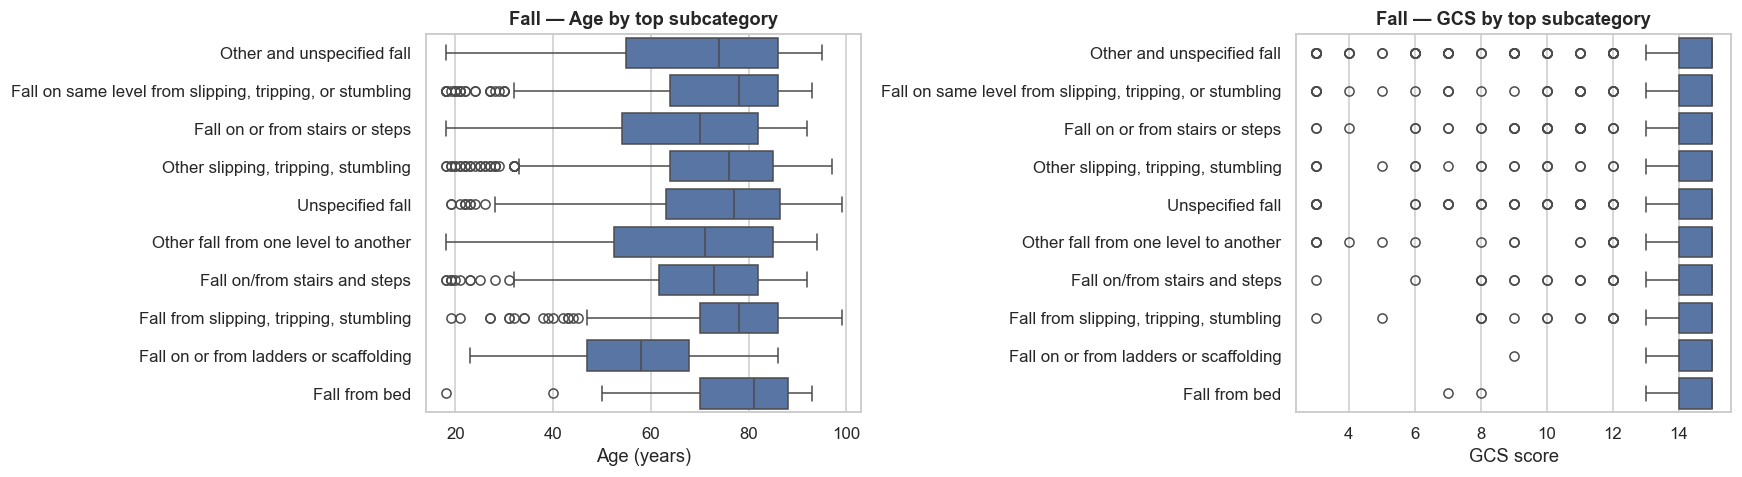

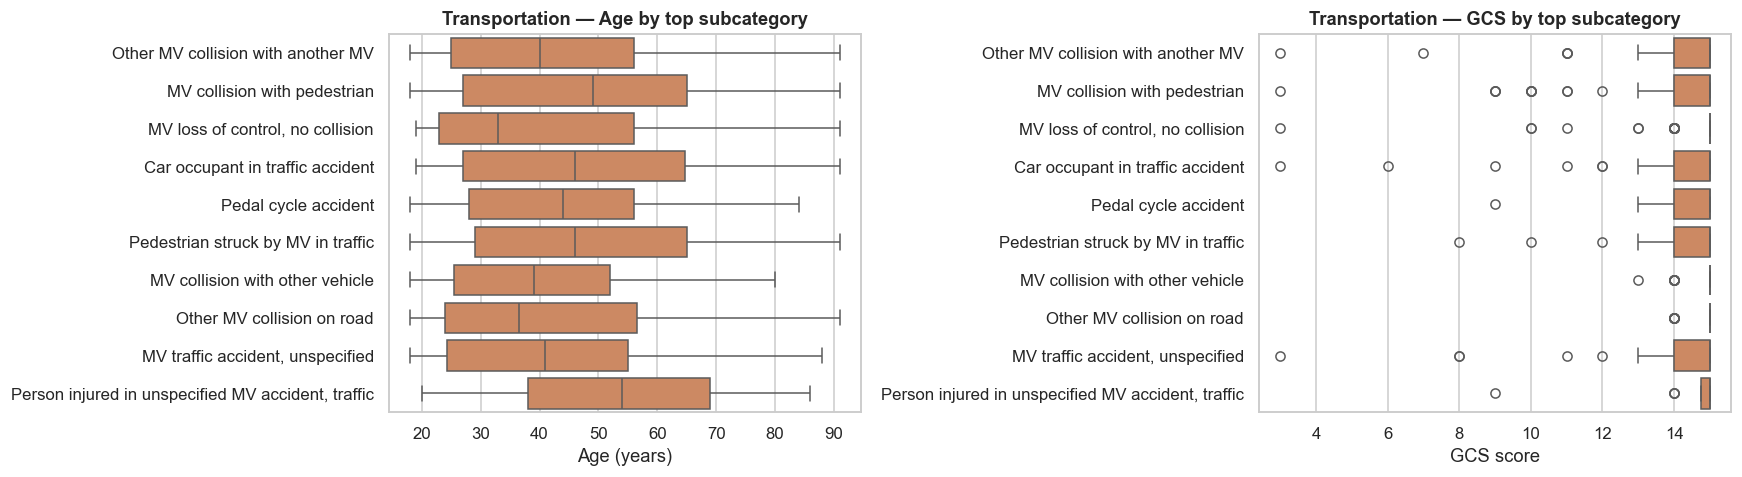

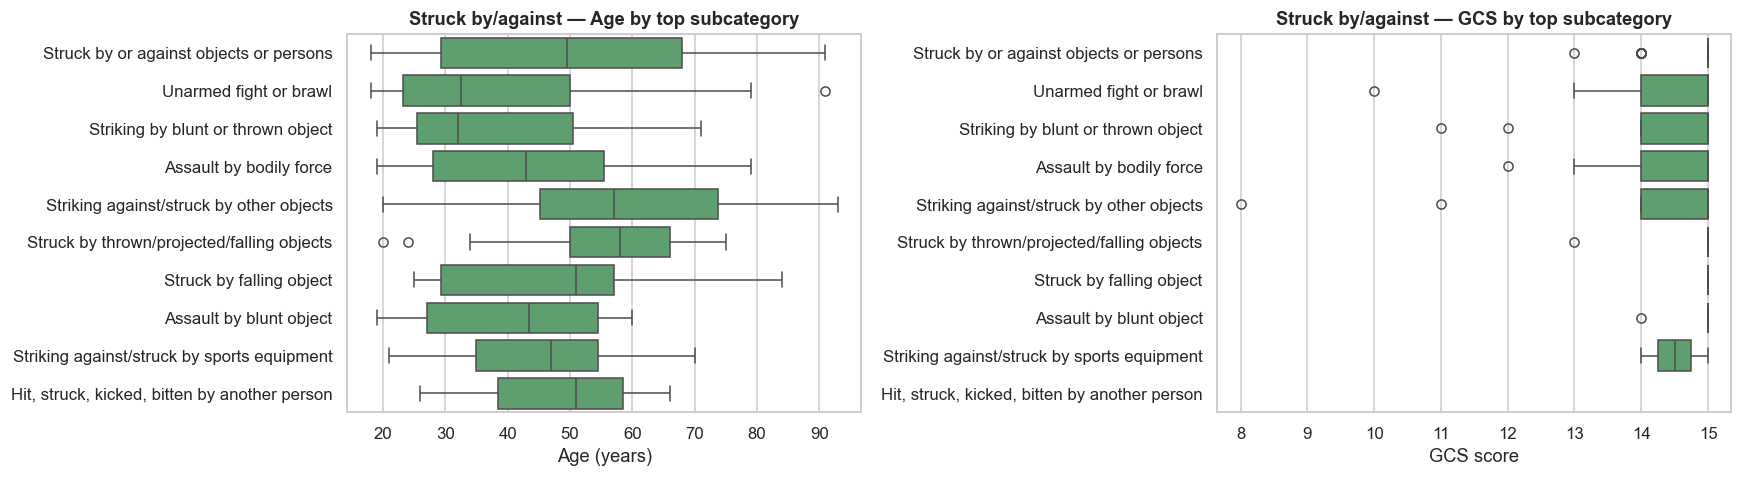

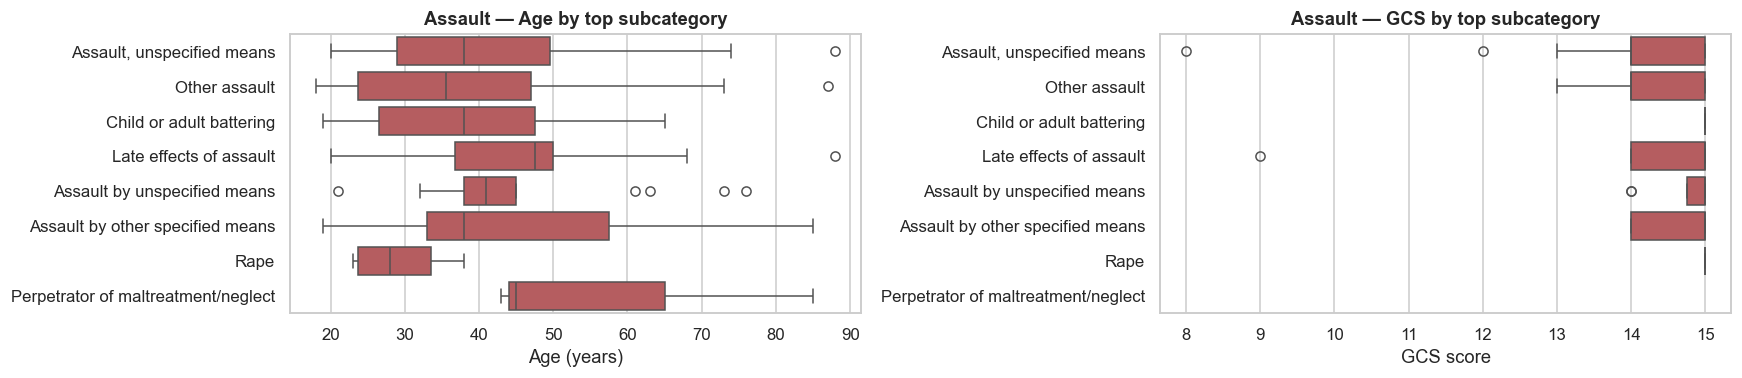

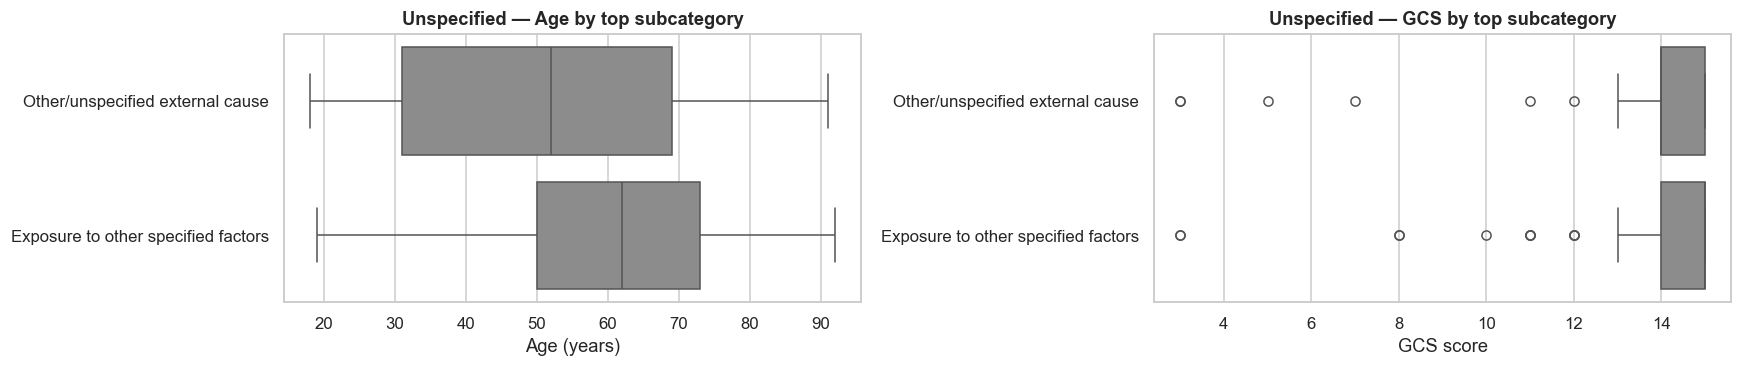

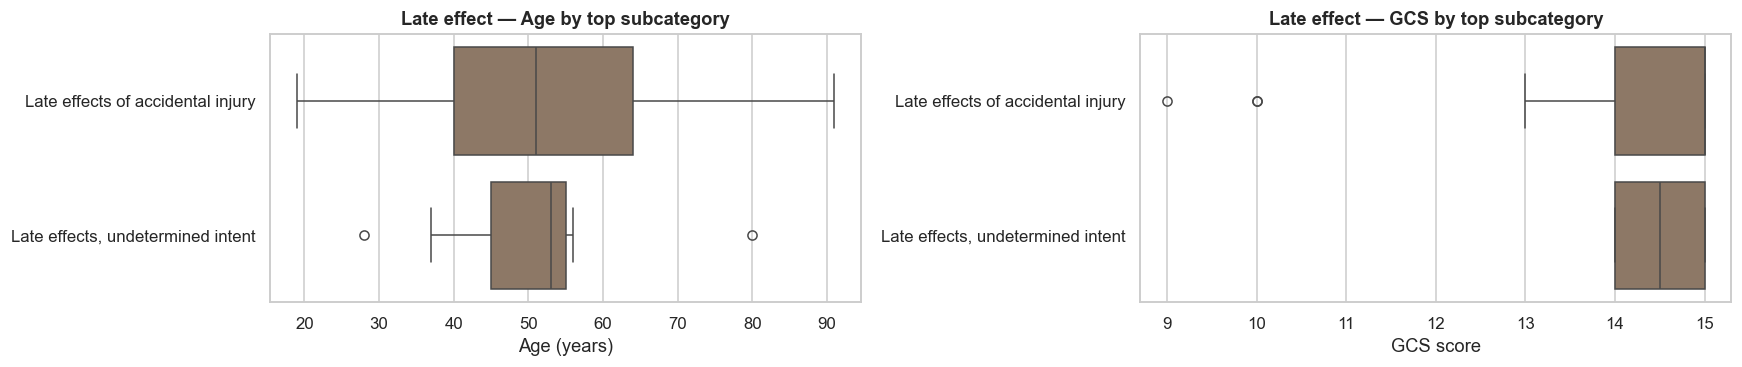

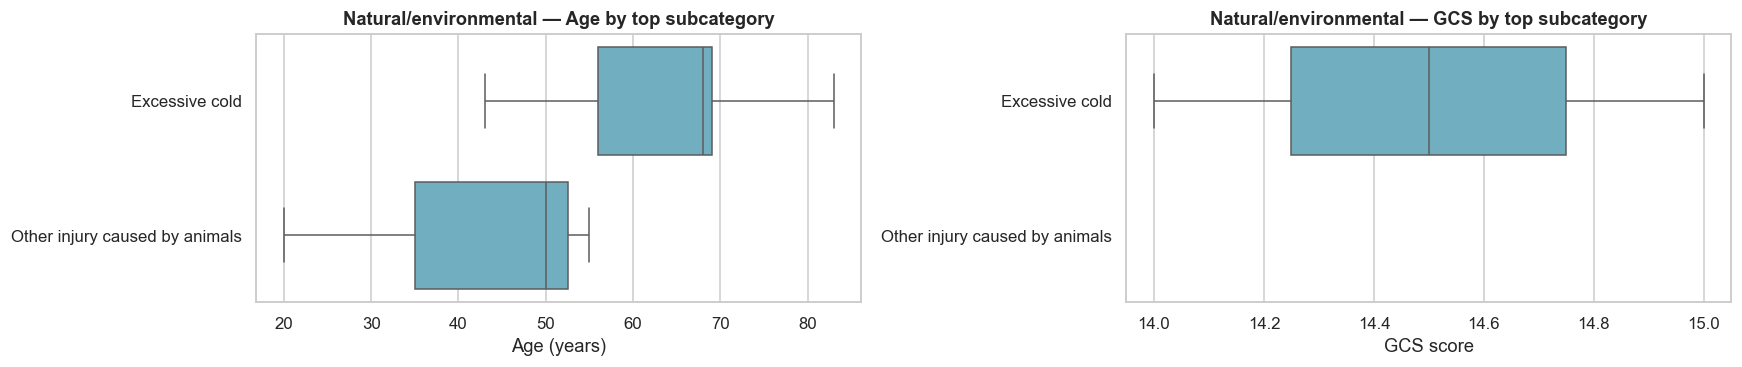

In [19]:
def value_long(top_subs, main_cat, col):
    out = []
    for sub, slice_df in patients_in_subs(main_cat, top_subs):
        for v in slice_df[col].dropna():
            out.append({"subcategory": sub, "value": v})
    return pd.DataFrame(out)

for c in SEVEN:
    if TOP_SUBS[c].empty:
        continue
    long_age = value_long(TOP_SUBS[c], c, "age_at_admission")
    long_gcs = value_long(TOP_SUBS[c], c, "last_gcs_score")
    if long_age.empty and long_gcs.empty:
        continue
    fig, axes = plt.subplots(1, 2, figsize=(16, max(3.5, 0.45 * len(TOP_SUBS[c]))))
    if not long_age.empty:
        sns.boxplot(data=long_age, y="subcategory", x="value", ax=axes[0],
                    order=list(TOP_SUBS[c].index), color=MAIN_COLORS[c])
        axes[0].set_title(f"{c} — Age by top subcategory")
        axes[0].set_xlabel("Age (years)"); axes[0].set_ylabel("")
    else:
        axes[0].set_visible(False)
    if not long_gcs.empty:
        sns.boxplot(data=long_gcs, y="subcategory", x="value", ax=axes[1],
                    order=list(TOP_SUBS[c].index), color=MAIN_COLORS[c])
        axes[1].set_title(f"{c} — GCS by top subcategory")
        axes[1].set_xlabel("GCS score"); axes[1].set_ylabel("")
    else:
        axes[1].set_visible(False)
    plt.tight_layout(); plt.show()

## 9 · Summary

In [20]:
print("=" * 64)
print(" TBI INCIDENT & OUTCOMES (v3, 7 families)  —  SUMMARY")
print("=" * 64)
print(f"Admissions analysed              : {len(df):,}")
print(f"With an incident main family     : {len(cat_df):,} "
      f"({len(cat_df)/len(df)*100:.1f}%)")
print()
print("Main-family split:")
for c in MAIN_CATS:
    n = (cat_df['main_category'] == c).sum()
    print(f"  {c:<25}: {n:>5,}  ({n/len(cat_df)*100:>5.1f}%)")
print()
print("Top subcategories carried into downstream analyses:")
for c in SEVEN:
    if TOP_SUBS[c].empty:
        continue
    print(f"\n  --- {c} ---")
    for sub, n in TOP_SUBS[c].items():
        print(f"    {n:>5,}  {sub}")

 TBI INCIDENT & OUTCOMES (v3, 7 families)  —  SUMMARY
Admissions analysed              : 9,723
With an incident main family     : 8,262 (85.0%)

Main-family split:
  Fall                     : 5,487  ( 66.4%)
  Transportation           : 1,599  ( 19.4%)
  Struck by/against        :   417  (  5.0%)
  Assault                  :   238  (  2.9%)
  Unspecified              :   191  (  2.3%)
  Late effect              :   170  (  2.1%)
  Natural/environmental    :     4  (  0.0%)
  Multiple                 :   156  (  1.9%)

Top subcategories carried into downstream analyses:

  --- Fall ---
    1,527  Other and unspecified fall
      825  Fall on same level from slipping, tripping, or stumbling
      615  Fall on or from stairs or steps
      592  Other slipping, tripping, stumbling
      579  Unspecified fall
      443  Other fall from one level to another
      340  Fall on/from stairs and steps
      307  Fall from slipping, tripping, stumbling
       86  Fall on or from ladders or scaff